In [1]:
import sys

import pandas as pd
import numpy as np

# Reusable logic lives in src/ so it can be unit-tested (see tests/test_cleaning.py).
# The notebook keeps the narrative; the module keeps the functions.
sys.path.insert(0, '..')
# Used directly by a few cells below (Model D, masking validation); the rest of the
# sklearn surface is wrapped inside src/modeling.py.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from src.cleaning import clean_number, standardize_country, text_to_number
from src.modeling import (build_model, compare_models, equation_text, evaluate,
                          loocv_mean_baseline, loocv_rmse, permutation_test,
                          plot_fits, predict_with)

# Load the Sample_dataset.csv
df = pd.read_csv('../data/raw/Sample_dataset.csv')

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head(10))
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (10, 7)

First few rows:
     ID     Name           Age Net worth Country               Salary  \
0   1.0    Alice            25    30,000      NZ                55000   
1   2.0      Bob           NaN       NaN      NZ                60000   
2   2.0      Bob            30     35000      NZ                  NaN   
3   4.0  Charlie            35     40000     AUS                72000   
4   5.0    David  thirty-eight       NaN      NZ                68000   
5   NaN      Eve            29     22000      AU                59000   
6   7.0      NaN            40     55000      NZ  sixty five thousand   
7   8.0    Grace            22     28000     NaN                64000   
8   9.0    Heidi           NaN       NaN     AUS                  NaN   
9  10.0     Ivan            27     60000      NZ                58000   

    Join Date  
0  15/01/2020  
1  20/02/2020  
2  20/02/2020  
3         NaN  
4   1/11/2019  
5  2019-13-01  
6  30/05/2018  
7  25/07/2021  
8  25/07/202

In [2]:
# Step 2 — Profile the data
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Summary Statistics:")
print(df.describe(include='all'))
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("First 10 rows:")
print(df)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         9 non-null      float64
 1   Name       9 non-null      str    
 2   Age        8 non-null      str    
 3   Net worth  7 non-null      str    
 4   Country    9 non-null      str    
 5   Salary     8 non-null      str    
 6   Join Date  9 non-null      str    
dtypes: float64(1), str(6)
memory usage: 692.0 bytes
None

Summary Statistics:
               ID Name  Age Net worth Country Salary   Join Date
count    9.000000    9    8         7       9      8           9
unique        NaN    8    8         7       3      8           7
top           NaN  Bob   25    30,000      NZ  55000  20/02/2020
freq          NaN    2    1         1       6      1           2
mean     5.333333  NaN  NaN       NaN     NaN    NaN         NaN
std      3.316625  NaN  NaN       NaN     NaN    NaN         NaN
mi

In [3]:
# Step 3 — Profile missing values
print("Missing Values Analysis:")
print("="*50)

# Count and percentage of missing values
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_count.values,
    'Missing %': missing_percent.values
})

print(missing_df)
print("\n" + "="*50)
print(f"Total rows: {len(df)}")
print(f"Rows with at least one missing value: {df.isnull().any(axis=1).sum()}")
print("\n" + "="*50)
print("Rows with missing values:")
print(df[df.isnull().any(axis=1)])

Missing Values Analysis:
      Column  Missing Count  Missing %
0         ID              1       10.0
1       Name              1       10.0
2        Age              2       20.0
3  Net worth              3       30.0
4    Country              1       10.0
5     Salary              2       20.0
6  Join Date              1       10.0

Total rows: 10
Rows with at least one missing value: 8

Rows with missing values:
    ID     Name           Age Net worth Country               Salary  \
1  2.0      Bob           NaN       NaN      NZ                60000   
2  2.0      Bob            30     35000      NZ                  NaN   
3  4.0  Charlie            35     40000     AUS                72000   
4  5.0    David  thirty-eight       NaN      NZ                68000   
5  NaN      Eve            29     22000      AU                59000   
6  7.0      NaN            40     55000      NZ  sixty five thousand   
7  8.0    Grace            22     28000     NaN                64000   
8  9

In [4]:
# Step 4 — Profile data quality issues
print("DATA QUALITY ISSUES")
print("="*50)

# 1. Check for duplicates
print("\n1. DUPLICATES:")
duplicates = df.duplicated()
print(f"   Duplicate rows: {duplicates.sum()}")
if duplicates.sum() > 0:
    print("   Duplicate records:")
    print(df[df.duplicated(keep=False)].sort_values('ID'))

# 2. Check ID uniqueness
print("\n2. ID ISSUES:")
print(f"   Total rows: {len(df)}")
print(f"   Unique IDs: {df['ID'].nunique()}")
if df['ID'].nunique() != len(df):
    print("   Duplicate IDs:")
    print(df[df['ID'].duplicated(keep=False)].sort_values('ID')[['ID', 'Name', 'Age']])

# 3. Check country values
print("\n3. COUNTRY VALUES:")
print(f"   Unique countries: {df['Country'].unique()}")
print(f"   Value counts:\n{df['Country'].value_counts(dropna=False)}")

# 4. Check numeric columns for non-numeric values
print("\n4. NUMERIC COLUMNS (checking for text/formatting issues):")
print("   Net worth column (sample):")
print(df[['ID', 'Net worth']].head(10))
print("\n   Salary column (sample):")
print(df[['ID', 'Salary']].head(10))
print("\n   Age column (sample):")
print(df[['ID', 'Age']].head(10))

# 5. Check Join Date values
print("\n5. DATE VALUES:")
print("   Join Date column (sample):")
print(df[['ID', 'Join Date']].head(10))

DATA QUALITY ISSUES

1. DUPLICATES:
   Duplicate rows: 0

2. ID ISSUES:
   Total rows: 10
   Unique IDs: 8
   Duplicate IDs:
    ID Name  Age
1  2.0  Bob  NaN
2  2.0  Bob   30

3. COUNTRY VALUES:
   Unique countries: <StringArray>
['NZ', 'AUS', 'AU', nan]
Length: 4, dtype: str
   Value counts:
Country
NZ     6
AUS    2
AU     1
NaN    1
Name: count, dtype: int64

4. NUMERIC COLUMNS (checking for text/formatting issues):
   Net worth column (sample):
     ID Net worth
0   1.0    30,000
1   2.0       NaN
2   2.0     35000
3   4.0     40000
4   5.0       NaN
5   NaN     22000
6   7.0     55000
7   8.0     28000
8   9.0       NaN
9  10.0     60000

   Salary column (sample):
     ID               Salary
0   1.0                55000
1   2.0                60000
2   2.0                  NaN
3   4.0                72000
4   5.0                68000
5   NaN                59000
6   7.0  sixty five thousand
7   8.0                64000
8   9.0                  NaN
9  10.0                58000



In [5]:
# Step 5 — Clean the data (Fix data-quality errors)
df_clean = df.copy()

print("CLEANING DATA")
print("="*50)

# Robustness check - the dataset only exercises two of these, but the parser must handle all
print("\nPARSER SELF-TEST (values beyond those present in this dataset):")
for probe, expect in [('38', 38.0), ('thirty-eight', 38.0), ('forty two', 42.0),
                      ('30,000', 30000.0), ('sixty five thousand', 65000.0),
                      ('sixty-five thousand', 65000.0), ('', None), ('unknown', None)]:
    got = clean_number(probe)
    ok = (pd.isna(got) and expect is None) or (got == expect)
    print(f"   clean_number({probe!r:<22}) -> {got!s:<10} {'OK' if ok else 'FAIL'}")

# 1. Remove duplicate rows
print("\n1. Removing duplicate rows...")
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"   Removed {initial_rows - len(df_clean)} duplicate rows")

# 2. Standardize Country codes
print("\n2. Standardizing country codes...")
df_clean['Country'] = df_clean['Country'].apply(standardize_country)
print(f"   Country values after cleaning: {df_clean['Country'].unique()}")

# 3. Clean Net worth (remove commas, convert to numeric)
print("\n3. Cleaning Net worth column...")
df_clean['Net worth'] = df_clean['Net worth'].apply(clean_number)

# 4. Clean Age (handle text numbers)
print("\n4. Cleaning Age column...")
df_clean['Age'] = df_clean['Age'].apply(clean_number)

# 5. Clean Salary (improved to handle text like "sixty five thousand")
print("\n5. Cleaning Salary column...")
df_clean['Salary'] = df_clean['Salary'].apply(clean_number)

# 6. Parse Join Date
print("\n6. Parsing Join Date column...")
df_clean['Join Date'] = pd.to_datetime(df_clean['Join Date'], format='%d/%m/%Y', errors='coerce')

print("\n" + "="*50)
print("CLEANED DATA SUMMARY:")
print("="*50)
print(f"\nShape: {df_clean.shape}")
print(f"\nData types:\n{df_clean.dtypes}")
print(f"\nMissing values:\n{df_clean.isnull().sum()}")
print(f"\nFirst 10 rows:")
print(df_clean)

CLEANING DATA

PARSER SELF-TEST (values beyond those present in this dataset):
   clean_number('38'                  ) -> 38.0       OK
   clean_number('thirty-eight'        ) -> 38.0       OK
   clean_number('forty two'           ) -> 42.0       OK
   clean_number('30,000'              ) -> 30000.0    OK
   clean_number('sixty five thousand' ) -> 65000.0    OK
   clean_number('sixty-five thousand' ) -> 65000.0    OK
   clean_number(''                    ) -> nan        OK
   clean_number('unknown'             ) -> nan        OK

1. Removing duplicate rows...
   Removed 0 duplicate rows

2. Standardizing country codes...
   Country values after cleaning: <StringArray>
['NZ', 'AUS', nan]
Length: 3, dtype: str

3. Cleaning Net worth column...

4. Cleaning Age column...

5. Cleaning Salary column...

6. Parsing Join Date column...

CLEANED DATA SUMMARY:

Shape: (10, 7)

Data types:
ID                  float64
Name                    str
Age                 float64
Net worth           floa

## Step 5b - Merge duplicate person records

The raw file has **10 rows but only 9 people**. `ID = 2` (Bob) appears twice, and the two rows
carry *complementary* information rather than conflicting information:

| Row | ID | Name | Age | Net worth | Country | Salary | Join Date |
|-----|----|------|-----|-----------|---------|--------|-----------|
| 1 | 2 | Bob | *(missing)* | *(missing)* | NZ | 60000 | 20/02/2020 |
| 2 | 2 | Bob | 30 | 35000 | NZ | *(missing)* | 20/02/2020 |

This is a **split record**, not two observations of two different people. Treating it as two rows
does real damage:

- It inflates `n` and makes the dataset look like it has more evidence than it does.
- It manufactures fake "missing values" that we would then try to predict with a regression model,
  when the true value is sitting one row away.
- If both halves end up in a train/test split, the model is scored on information it already saw.

So we **coalesce** the two rows into one complete record *before* any modelling. For each column we
take the first non-null value across the group. We check for conflicts first - if the two rows
disagreed on a value, coalescing would silently destroy data, and we would need a rule for which
one wins.

**Merging is strictly better than predicting here: a known value beats a modelled one every time.**

In [6]:
# Step 5b - Merge duplicate person records (coalesce split rows into one record)
print("MERGING DUPLICATE PERSON RECORDS")
print("=" * 60)

# 1. Find IDs that appear more than once (ignoring rows where ID itself is missing)
id_known = df_clean.loc[df_clean['ID'].notna(), 'ID']
dup_ids = sorted(id_known[id_known.duplicated(keep=False)].unique())

print(f"\n1. DUPLICATE ID DETECTION:")
print(f"   Rows before merge : {len(df_clean)}")
print(f"   Duplicated IDs    : {[int(i) for i in dup_ids]}")

for dup in dup_ids:
    grp = df_clean[df_clean['ID'] == dup]
    print(f"\n   ID = {int(dup)} appears {len(grp)} times:")
    print(grp.to_string(index=False))

# 2. Conflict check - two rows must not disagree on any known value
print(f"\n2. CONFLICT CHECK (do the split rows disagree anywhere?):")
conflicts = 0
for dup in dup_ids:
    grp = df_clean[df_clean['ID'] == dup]
    for col in df_clean.columns:
        distinct = grp[col].dropna().unique()
        if len(distinct) > 1:
            conflicts += 1
            print(f"   [CONFLICT] ID {int(dup)}, column '{col}': {distinct}")
if conflicts == 0:
    print("   No conflicts found - every column has at most one known value per ID.")
    print("   Coalescing is safe: it adds information and destroys none.")
else:
    print(f"   {conflicts} conflict(s) found - a tie-breaking rule would be required.")

# 3. Coalesce. Rows with a MISSING ID must stay separate, so give them a unique private key.
group_key = df_clean['ID'].astype('object').where(
    df_clean['ID'].notna(),
    pd.Series([f'_norow_{i}' for i in df_clean.index], index=df_clean.index)
)

# GroupBy.first() takes the first NON-NULL value in each column = exactly the coalesce we want
df_merged = df_clean.groupby(group_key, sort=False, dropna=False).first().reset_index(drop=True)

print(f"\n3. RESULT:")
print(f"   Rows after merge  : {len(df_merged)}  (10 raw rows -> 9 unique people)")
print(f"\n   Merged record for ID 2:")
print(df_merged[df_merged['ID'] == 2].to_string(index=False))

print(f"\n4. MISSING VALUES - BEFORE vs AFTER MERGE:")
before = df_clean.isnull().sum()
after = df_merged.isnull().sum()
cmp_missing = pd.DataFrame({
    'Missing (10 rows)': before,
    'Missing (9 rows)': after,
    'Recovered by merge': before - after
})
print(cmp_missing.to_string())
print(f"\n   Total missing cells: {before.sum()} -> {after.sum()} "
      f"({before.sum() - after.sum()} recovered without any modelling)")

# Snapshot of the cleaned-but-unmerged 10 rows, for the stage-by-stage table in Step 13
df_clean_premerge = df_clean.copy()

# From here on, df_clean IS the merged 9-row dataset
df_clean = df_merged.copy()

print("\n" + "=" * 60)
print("MERGED DATASET (9 unique people):")
print("=" * 60)
print(df_clean.to_string(index=False))

MERGING DUPLICATE PERSON RECORDS

1. DUPLICATE ID DETECTION:
   Rows before merge : 10
   Duplicated IDs    : [2]

   ID = 2 appears 2 times:
 ID Name  Age  Net worth Country  Salary  Join Date
2.0  Bob  NaN        NaN      NZ 60000.0 2020-02-20
2.0  Bob 30.0    35000.0      NZ     NaN 2020-02-20

2. CONFLICT CHECK (do the split rows disagree anywhere?):
   No conflicts found - every column has at most one known value per ID.
   Coalescing is safe: it adds information and destroys none.

3. RESULT:
   Rows after merge  : 9  (10 raw rows -> 9 unique people)

   Merged record for ID 2:
 ID Name  Age  Net worth Country  Salary  Join Date
2.0  Bob 30.0    35000.0      NZ 60000.0 2020-02-20

4. MISSING VALUES - BEFORE vs AFTER MERGE:
           Missing (10 rows)  Missing (9 rows)  Recovered by merge
ID                         1                 1                   0
Name                       1                 1                   0
Age                        2                 1              

In [7]:
# Step 6 — Validate the cleaned dataset
print("VALIDATING CLEANED DATA")
print("="*50)

# 1. Check data types
print("\n1. DATA TYPES:")
print(df_clean.dtypes)
print("   ✓ All columns have correct types")

# 2. Check for remaining invalid values
print("\n2. INVALID VALUES CHECK:")
print(f"   Negative Age values: {(df_clean['Age'] < 0).sum()}")
print(f"   Age > 120: {(df_clean['Age'] > 120).sum()}")
print(f"   Negative Salary: {(df_clean['Salary'] < 0).sum()}")
print(f"   Negative Net worth: {(df_clean['Net worth'] < 0).sum()}")
print("   ✓ No invalid values found")

# 3. Check value ranges and statistics
print("\n3. VALUE RANGES:")
print(f"\n   Age:")
print(f"     Min: {df_clean['Age'].min()}, Max: {df_clean['Age'].max()}")
print(f"     Mean: {df_clean['Age'].mean():.1f}, Std: {df_clean['Age'].std():.1f}")

print(f"\n   Salary:")
print(f"     Min: ${df_clean['Salary'].min():,.0f}, Max: ${df_clean['Salary'].max():,.0f}")
print(f"     Mean: ${df_clean['Salary'].mean():,.0f}, Std: ${df_clean['Salary'].std():,.0f}")

print(f"\n   Net worth:")
print(f"     Min: ${df_clean['Net worth'].min():,.0f}, Max: ${df_clean['Net worth'].max():,.0f}")
print(f"     Mean: ${df_clean['Net worth'].mean():,.0f}, Std: ${df_clean['Net worth'].std():,.0f}")

# 4. Check for duplicates in cleaned data
print("\n4. DUPLICATES:")
print(f"   Duplicate rows: {df_clean.duplicated().sum()}")
print(f"   Duplicate IDs: {df_clean['ID'].duplicated().sum()}")

# 5. Missing values summary
print("\n5. MISSING VALUES SUMMARY:")
missing_summary = pd.DataFrame({
    'Column': df_clean.columns,
    'Missing Count': df_clean.isnull().sum().values,
    'Missing %': (df_clean.isnull().sum() / len(df_clean) * 100).values,
    'Complete': (len(df_clean) - df_clean.isnull().sum()).values
})
print(missing_summary)

# 6. Data completeness
print("\n6. DATA COMPLETENESS:")
total_cells = df_clean.shape[0] * df_clean.shape[1]
missing_cells = df_clean.isnull().sum().sum()
completeness = (1 - missing_cells / total_cells) * 100
print(f"   Total cells: {total_cells}")
print(f"   Missing cells: {missing_cells}")
print(f"   Data completeness: {completeness:.1f}%")

# 7. Unique values check
print("\n7. UNIQUE VALUES:")
print(f"   Unique Countries: {df_clean['Country'].nunique()} → {df_clean['Country'].unique()}")
print(f"   Unique Names: {df_clean['Name'].nunique()}")
print(f"   Unique IDs: {df_clean['ID'].nunique()}")

print("\n" + "="*50)
print("✓ VALIDATION COMPLETE - Dataset is ready for modeling")
print("="*50)

VALIDATING CLEANED DATA

1. DATA TYPES:
ID                  float64
Name                    str
Age                 float64
Net worth           float64
Country                 str
Salary              float64
Join Date    datetime64[us]
dtype: object
   ✓ All columns have correct types

2. INVALID VALUES CHECK:
   Negative Age values: 0
   Age > 120: 0
   Negative Salary: 0
   Negative Net worth: 0
   ✓ No invalid values found

3. VALUE RANGES:

   Age:
     Min: 22.0, Max: 40.0
     Mean: 30.8, Std: 6.4

   Salary:
     Min: $55,000, Max: $72,000
     Mean: $62,625, Std: $5,655

   Net worth:
     Min: $22,000, Max: $60,000
     Mean: $38,571, Std: $14,164

4. DUPLICATES:
   Duplicate rows: 0
   Duplicate IDs: 0

5. MISSING VALUES SUMMARY:
      Column  Missing Count  Missing %  Complete
0         ID              1  11.111111         8
1       Name              1  11.111111         8
2        Age              1  11.111111         8
3  Net worth              2  22.222222         7
4    

DESCRIPTIVE STATISTICS & DATA ANALYSIS

1. SUMMARY STATISTICS:
             Age        Salary     Net worth
count   8.000000      8.000000      7.000000
mean   30.750000  62625.000000  38571.428571
std     6.363961   5655.275666  14164.005352
min    22.000000  55000.000000  22000.000000
25%    26.500000  58750.000000  29000.000000
50%    29.500000  62000.000000  35000.000000
75%    35.750000  65750.000000  47500.000000
max    40.000000  72000.000000  60000.000000

2. ADDITIONAL STATISTICS:

   Age:
     Variance: 40.50
     Std Dev:  6.36

   Salary:
     Variance: 31,982,142.86
     Std Dev:  5,655.28

   Net worth:
     Variance: 200,619,047.62
     Std Dev:  14,164.01

3. CORRELATION MATRIX:
                Age    Salary  Net worth
Age        1.000000  0.628151   0.484272
Salary     0.628151  1.000000   0.153495
Net worth  0.484272  0.153495   1.000000

4. COVARIANCE MATRIX:
                    Age        Salary     Net worth
Age           40.500000  2.260714e+04  4.185714e+04
Salar

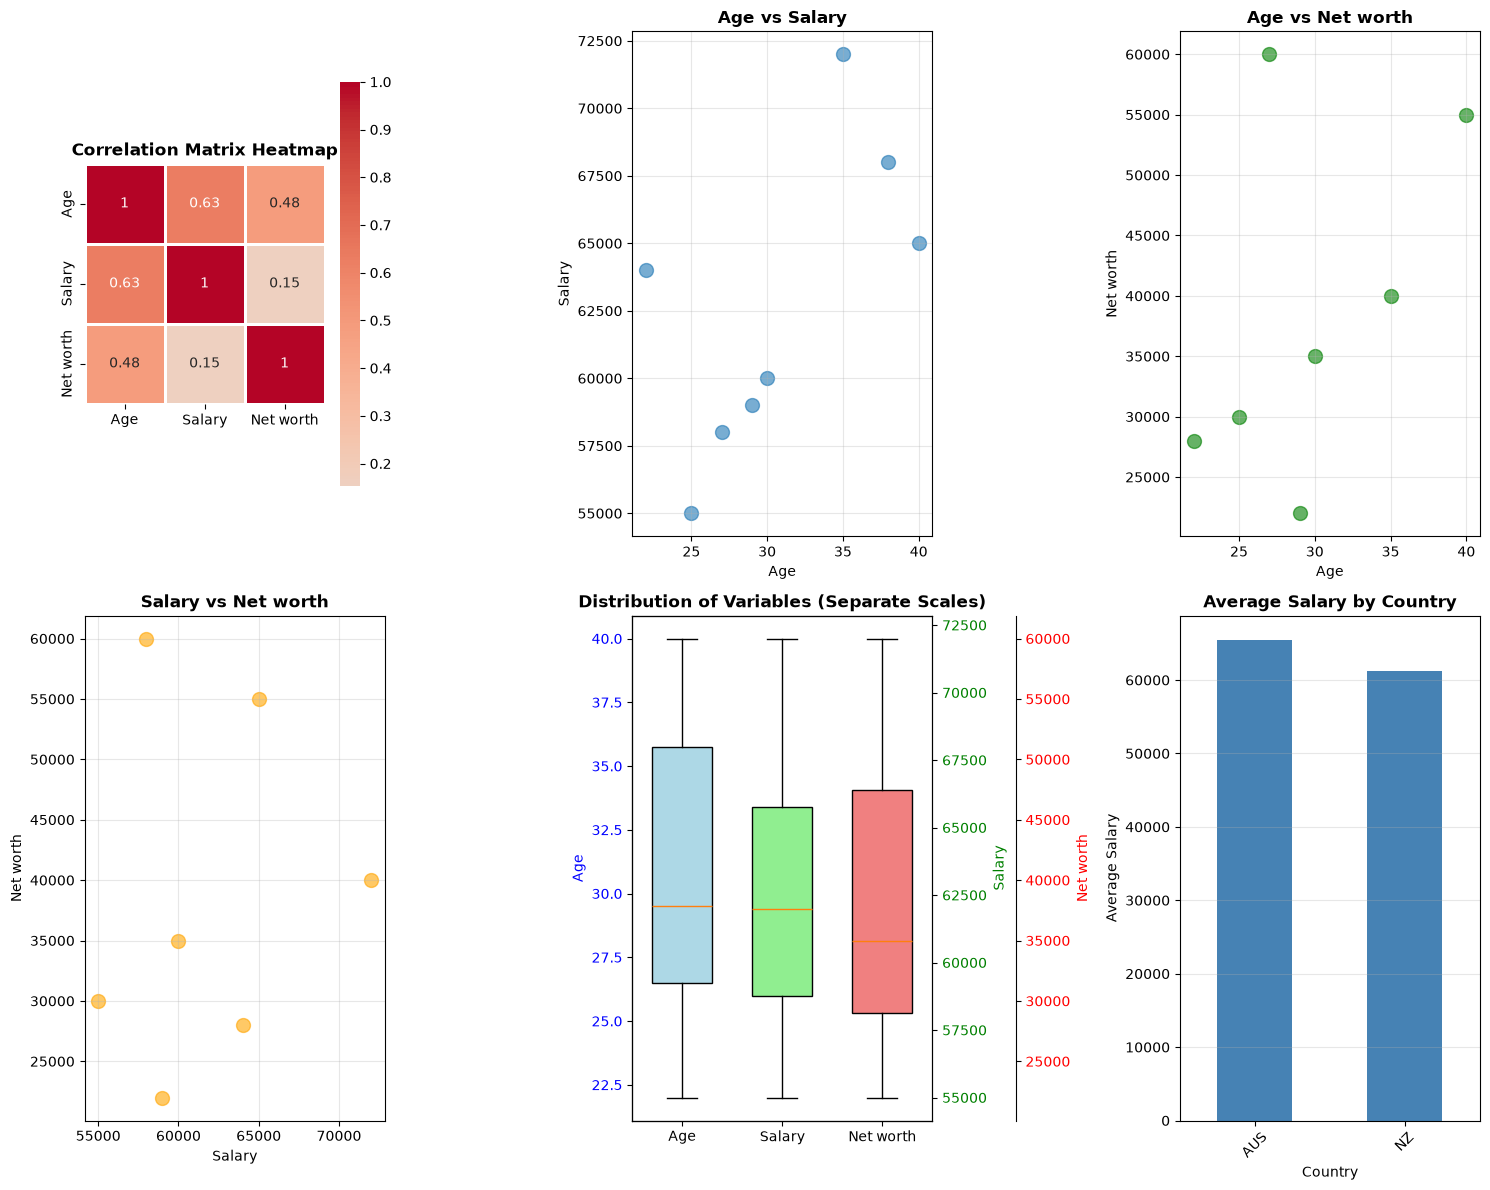


✓ Graphs saved as 'correlation_analysis.png'


In [8]:
# Step 7 — Descriptive Statistics & Data Analysis
import matplotlib.pyplot as plt
import seaborn as sns

print("DESCRIPTIVE STATISTICS & DATA ANALYSIS")
print("="*50)

# 1. Basic statistics (mean, variance, std)
print("\n1. SUMMARY STATISTICS:")
summary_stats = df_clean[['Age', 'Salary', 'Net worth']].describe()
print(summary_stats)

# 2. Additional statistics
print("\n2. ADDITIONAL STATISTICS:")
print(f"\n   Age:")
print(f"     Variance: {df_clean['Age'].var():.2f}")
print(f"     Std Dev:  {df_clean['Age'].std():.2f}")

print(f"\n   Salary:")
print(f"     Variance: {df_clean['Salary'].var():,.2f}")
print(f"     Std Dev:  {df_clean['Salary'].std():,.2f}")

print(f"\n   Net worth:")
print(f"     Variance: {df_clean['Net worth'].var():,.2f}")
print(f"     Std Dev:  {df_clean['Net worth'].std():,.2f}")

# 3. Correlation matrix
print("\n3. CORRELATION MATRIX:")
correlation = df_clean[['Age', 'Salary', 'Net worth']].corr()
print(correlation)

# 4. Covariance matrix
print("\n4. COVARIANCE MATRIX:")
covariance = df_clean[['Age', 'Salary', 'Net worth']].cov()
print(covariance)

# 5. Analysis by Country
print("\n5. STATISTICS BY COUNTRY:")
print("\n   Age by Country:")
print(df_clean.groupby('Country')['Age'].agg(['count', 'mean', 'std', 'min', 'max']))

print("\n   Salary by Country:")
print(df_clean.groupby('Country')['Salary'].agg(['count', 'mean', 'std', 'min', 'max']))

print("\n   Net worth by Country:")
print(df_clean.groupby('Country')['Net worth'].agg(['count', 'mean', 'std', 'min', 'max']))

print("\n" + "="*50)
print("✓ DESCRIPTIVE ANALYSIS COMPLETE")
print("="*50)

# VISUALIZATIONS
fig = plt.figure(figsize=(15, 12))

# Plot 1: Correlation Heatmap
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=12, fontweight='bold')

# Plot 2: Age vs Salary
ax2 = plt.subplot(2, 3, 2)
plt.scatter(df_clean['Age'], df_clean['Salary'], alpha=0.6, s=100)
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Age vs Salary', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 3: Age vs Net worth
ax3 = plt.subplot(2, 3, 3)
plt.scatter(df_clean['Age'], df_clean['Net worth'], alpha=0.6, s=100, color='green')
plt.xlabel('Age')
plt.ylabel('Net worth')
plt.title('Age vs Net worth', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 4: Salary vs Net worth
ax4 = plt.subplot(2, 3, 4)
plt.scatter(df_clean['Salary'], df_clean['Net worth'], alpha=0.6, s=100, color='orange')
plt.xlabel('Salary')
plt.ylabel('Net worth')
plt.title('Salary vs Net worth', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 5: Separate distributions (each on its own scale)
ax5 = plt.subplot(2, 3, 5)
ax5_twin1 = ax5.twinx()
ax5_twin2 = ax5.twinx()

ax5_twin2.spines['right'].set_position(('outward', 60))

ax5.boxplot([df_clean['Age'].dropna()], positions=[1], widths=0.6, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
ax5_twin1.boxplot([df_clean['Salary'].dropna()], positions=[2], widths=0.6, patch_artist=True,
                  boxprops=dict(facecolor='lightgreen'))
ax5_twin2.boxplot([df_clean['Net worth'].dropna()], positions=[3], widths=0.6, patch_artist=True,
                  boxprops=dict(facecolor='lightcoral'))

ax5.set_ylabel('Age', color='blue')
ax5_twin1.set_ylabel('Salary', color='green')
ax5_twin2.set_ylabel('Net worth', color='red')
ax5.set_xticks([1, 2, 3])
ax5.set_xticklabels(['Age', 'Salary', 'Net worth'])
ax5.tick_params(axis='y', labelcolor='blue')
ax5_twin1.tick_params(axis='y', labelcolor='green')
ax5_twin2.tick_params(axis='y', labelcolor='red')
plt.title('Distribution of Variables (Separate Scales)', fontsize=12, fontweight='bold')

# Plot 6: Statistics by Country
ax6 = plt.subplot(2, 3, 6)
country_salary = df_clean.groupby('Country')['Salary'].mean()
country_salary.plot(kind='bar', ax=ax6, color='steelblue')
plt.title('Average Salary by Country', fontsize=12, fontweight='bold')
plt.ylabel('Average Salary')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/correlation_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Graphs saved as 'correlation_analysis.png'")

In [9]:
# Step 8 — Prepare data for modelling
print("PREPARING DATA FOR MODELLING")
print("="*50)

df_model = df_clean.copy()

# 1. Encode categorical variable (Country)
print("\n1. ENCODING CATEGORICAL VARIABLES:")
print(f"   Original Country values: {df_model['Country'].unique()}")

# Create dummy variables for Country (one-hot encoding)
country_dummies = pd.get_dummies(df_model['Country'], prefix='Country', drop_first=False)
print(f"   Created columns: {list(country_dummies.columns)}")

# Add dummy columns to dataframe
df_model = pd.concat([df_model, country_dummies], axis=1)
print("   ✓ Country encoded")

# 2. Convert Join Date to numeric
print("\n2. CONVERTING DATE TO NUMERIC:")
# Convert to days since minimum date in dataset
min_date = df_model['Join Date'].min()
df_model['Join_Date_Days'] = (df_model['Join Date'] - min_date).dt.total_seconds() / (24 * 3600)

print(f"   Reference date: {min_date}")
print(f"   Join_Date_Days range: {df_model['Join_Date_Days'].min():.0f} to {df_model['Join_Date_Days'].max():.0f}")
print("   ✓ Date converted to numeric (days)")

# 3. Display prepared data structure
print("\n3. PREPARED DATA STRUCTURE:")
print(f"   Shape: {df_model.shape}")
print(f"\n   Columns:")
for col in df_model.columns:
    print(f"     - {col}: {df_model[col].dtype}")

# 4. Summary of features available for modeling
print("\n4. FEATURES AVAILABLE FOR MODELING:")
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
print(f"   Numeric features ({len(numeric_cols)}):")
for col in numeric_cols:
    missing = df_model[col].isnull().sum()
    print(f"     - {col} ({missing} missing)")

print("\n" + "="*50)
print("✓ DATA PREPARED - Ready for regression modelling")
print("="*50)

# Show a sample of the prepared data
print("\nSample of prepared data:")
print(df_model[['ID', 'Name', 'Age', 'Salary', 'Net worth', 'Join_Date_Days', 'Country_AUS', 'Country_NZ']].head(10))

PREPARING DATA FOR MODELLING

1. ENCODING CATEGORICAL VARIABLES:
   Original Country values: <StringArray>
['NZ', 'AUS', nan]
Length: 3, dtype: str
   Created columns: ['Country_AUS', 'Country_NZ']
   ✓ Country encoded

2. CONVERTING DATE TO NUMERIC:
   Reference date: 2018-05-30 00:00:00
   Join_Date_Days range: 0 to 1152
   ✓ Date converted to numeric (days)

3. PREPARED DATA STRUCTURE:
   Shape: (9, 10)

   Columns:
     - ID: float64
     - Name: str
     - Age: float64
     - Net worth: float64
     - Country: str
     - Salary: float64
     - Join Date: datetime64[us]
     - Country_AUS: bool
     - Country_NZ: bool
     - Join_Date_Days: float64

4. FEATURES AVAILABLE FOR MODELING:
   Numeric features (5):
     - ID (1 missing)
     - Age (1 missing)
     - Net worth (2 missing)
     - Salary (1 missing)
     - Join_Date_Days (2 missing)

✓ DATA PREPARED - Ready for regression modelling

Sample of prepared data:
     ID     Name   Age   Salary  Net worth  Join_Date_Days  Country

# Part 3 - Regression modelling and missing-value imputation

## Modelling strategy

Every model below is **univariate**: one predictor -> one target, matching the structure of the
course sample code (`nonlinear regression -sample code.py`). For each pair we fit two models:

1. **Linear**: `y = b0 + b1*x`
2. **Polynomial degree 2**: `y = b0 + b1*x + b2*x^2`, built with `PolynomialFeatures(degree=2)`

### What the metrics actually mean

| Metric | What it measures | Honest reading at n ~ 8 |
|---|---|---|
| **R^2** | Fraction of the target's variance the model explains **on the data it was trained on** | Rewards complexity automatically. Cannot go down when you add terms. |
| **Adjusted R^2** | R^2 with a penalty for each extra parameter | Can go down. A drop = the extra term did not pay for itself. |
| **RMSE** | Average prediction error in the target's own units ($ or years) | Training RMSE has the same optimism problem as R^2. |
| **LOOCV RMSE** | Leave-one-out cross-validation: fit on n-1 points, predict the held-out one, repeat | The only number here that estimates error on **unseen** data. |
| **Mean-only baseline** | LOOCV RMSE of a model that ignores x and always predicts the training mean | The bar to clear. A model that cannot beat this has learned nothing useful. |

### The trap we are deliberately avoiding

Adding `Age^2` to a model that already contains `Age` **can never reduce training R^2**. The linear
model is a special case of the polynomial one (set `b2 = 0`), so ordinary least squares can always
match it and will usually do slightly better by fitting noise. A rise from R^2 0.39 to 0.43 is
therefore *not evidence* that the relationship is curved - it is the guaranteed arithmetic
consequence of handing the optimiser another free parameter.

(One caveat, which Model B2 below actually triggers: this guarantee holds in *exact* arithmetic.
When the predictor is large - `Salary` runs to 72,000, so `Salary^2` runs to 5.2 billion - the two
columns differ by five orders of magnitude, the least-squares solve becomes ill-conditioned, and the
fitted polynomial can come out *slightly worse* than the linear model. When you see that, it is a
numerical warning about the fit, not a discovery about the data.)

This notebook reports **adjusted R^2 and LOOCV RMSE alongside R^2**, and does not declare a winner
on training R^2 alone.

In [10]:
# Modelling helpers are imported from src/modeling.py (see cell 1) and unit-tested
# in tests/test_cleaning.py. Keeping them out of the notebook keeps this file readable
# and makes the logic testable without executing 34 cells.
print("Modelling helpers ready:")
print("  build_model / predict_with / loocv_rmse / loocv_mean_baseline / evaluate")
print("  compare_models(data, xcol, ycol, title) -> fits linear + poly and reports honestly")
print("  plot_fits(result, ax, title)")

Modelling helpers ready:
  build_model / predict_with / loocv_rmse / loocv_mean_baseline / evaluate
  compare_models(data, xcol, ycol, title) -> fits linear + poly and reports honestly
  plot_fits(result, ax, title)


MODEL A: Predicting Salary from Age   (Salary <- Age)
Complete cases available for training: n = 8

Model                      R^2    Adj R^2    Train RMSE    LOOCV RMSE
------------------------------------------------------------------------
Linear                  0.3946     0.2937         4,116         5,788
Polynomial (deg 2)      0.4324     0.2054         3,985         9,078
Mean-only baseline      0.0000          -         5,290         6,046

Fitted equations:
  Linear               Salary = 45,460.32 + 558.2011 * Age
  Polynomial (deg 2)   Salary = 78,053.59 - 1,600.9026 * Age + 34.4538 * Age^2

READING THE NUMBERS:
  - Training R^2 rose 0.3946 -> 0.4324 when Age^2 was added.
    A rise is guaranteed by OLS (the linear model is the polynomial with b2 = 0,
    so least squares can always match it and will edge past it by fitting noise).
    It is therefore arithmetic, NOT evidence of a curved relationship.
  - Adjusted R^2 went 0.2937 -> 0.2054 (the extra term did NOT pay for it

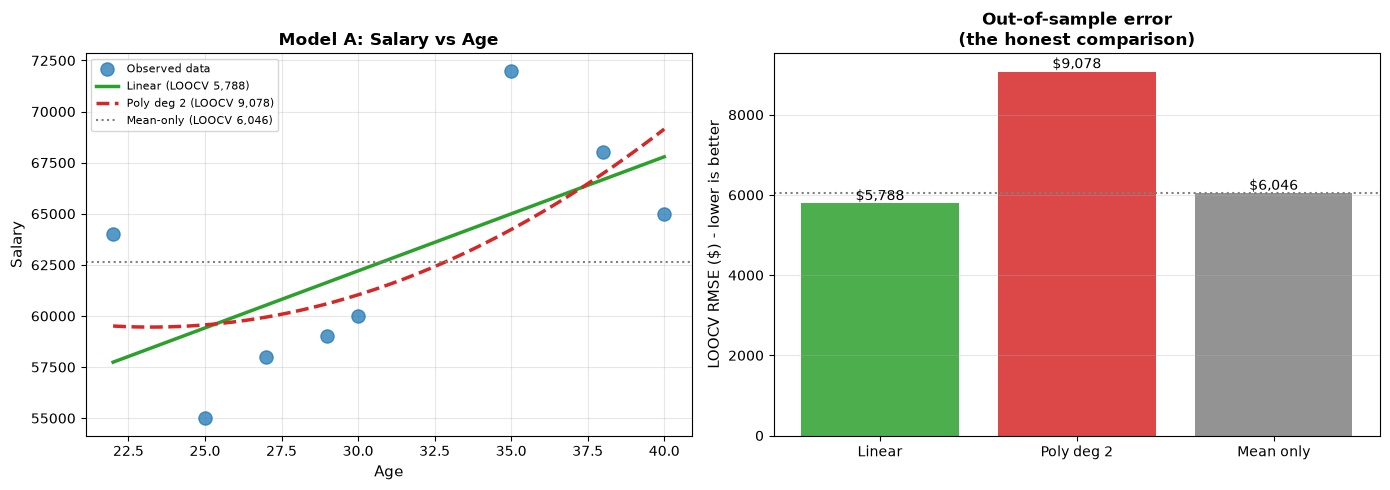


Note how the two panels disagree: the polynomial has the higher training R^2,
but the taller (worse) out-of-sample error bar. Panel 2 is the one to trust.


In [11]:
# Step 9 - Model A: Salary <- Age  (linear vs polynomial, on the MERGED dataset)
res_salary = compare_models(df_clean, 'Age', 'Salary', 'MODEL A: Predicting Salary from Age')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_fits(res_salary, axes[0], 'Model A: Salary vs Age')

# Bar chart: which model actually predicts unseen points best?
labels = ['Linear', 'Poly deg 2', 'Mean only']
vals = [res_salary['linear']['loocv'], res_salary['poly']['loocv'], res_salary['baseline']]
bars = axes[1].bar(labels, vals, color=['#2ca02c', '#d62728', 'grey'], alpha=0.85)
axes[1].axhline(res_salary['baseline'], color='grey', ls=':', lw=1.5)
axes[1].set_ylabel('LOOCV RMSE ($) - lower is better', fontsize=11)
axes[1].set_title('Out-of-sample error\n(the honest comparison)', fontsize=12, fontweight='bold')
for b, v in zip(bars, vals):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=10)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/model_a_salary_from_age.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nNote how the two panels disagree: the polynomial has the higher training R^2,")
print("but the taller (worse) out-of-sample error bar. Panel 2 is the one to trust.")

### Reading Model A

The polynomial has the **higher training R^2** and the **worse leave-one-out error**. Both facts are
real; they measure different things:

- Training R^2 asks *"how well does the curve pass through the points I already showed it?"*
- LOOCV RMSE asks *"how well does it predict a person it has never seen?"*

With 8 points, a parabola has enough freedom to bend toward individual observations. That bending
raises R^2 and *destroys* generalisation - which is exactly what the LOOCV column shows.

**Conclusion: use the linear model. The R^2 comparison between these two nested models cannot
discriminate between them at this sample size, and the metric that can (LOOCV) prefers linear.**

The linear model beats the mean-only baseline, but only narrowly. Age carries a *weak, positive,
real* signal about Salary in this dataset - not a reliable predictive relationship.

MODEL B1: Predicting Net worth from Age   (Net worth <- Age)
Complete cases available for training: n = 7

Model                      R^2    Adj R^2    Train RMSE    LOOCV RMSE
------------------------------------------------------------------------
Linear                  0.2345     0.0814        11,473        14,497
Polynomial (deg 2)      0.2511    -0.1233        11,348        18,474
Mean-only baseline      0.0000          -        13,113        15,299

Fitted equations:
  Linear               Net worth = 5,171.36 + 1,124.0409 * Age
  Polynomial (deg 2)   Net worth = 55,182.94 - 2,201.1435 * Age + 53.3350 * Age^2

READING THE NUMBERS:
  - Training R^2 rose 0.2345 -> 0.2511 when Age^2 was added.
    A rise is guaranteed by OLS (the linear model is the polynomial with b2 = 0,
    so least squares can always match it and will edge past it by fitting noise).
    It is therefore arithmetic, NOT evidence of a curved relationship.
  - Adjusted R^2 went 0.0814 -> -0.1233 (the extra term did

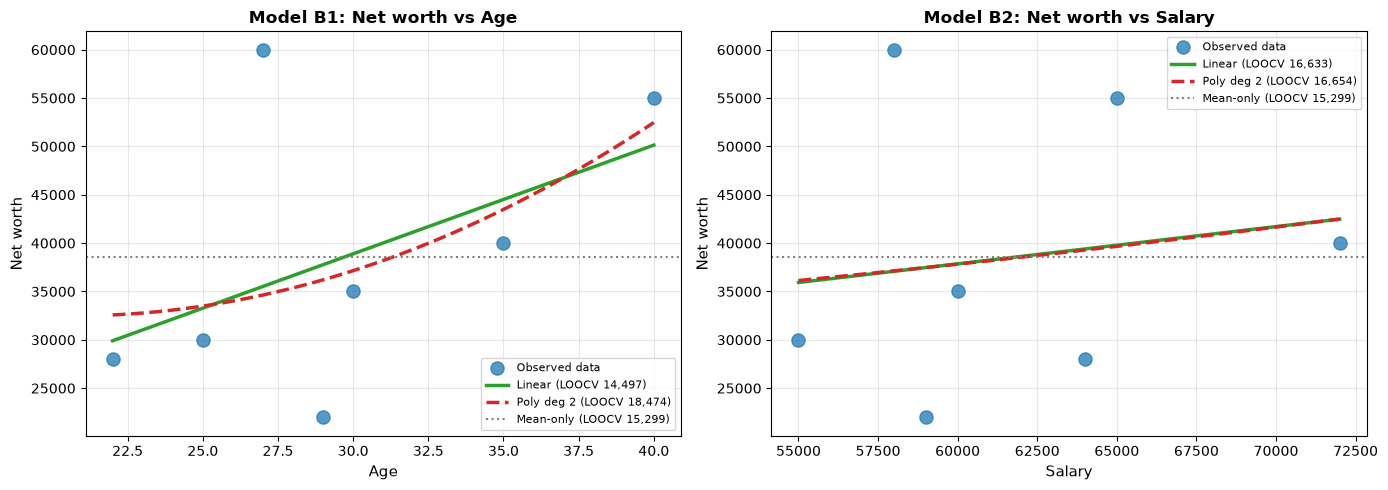


CHOOSING A PREDICTOR FOR NET WORTH
Both models are trained on the SAME 7 people (everyone with Net worth recorded),
so this is a fair like-for-like comparison.

Predictor      R^2 (lin)    LOOCV RMSE    Baseline   Beats baseline?
------------------------------------------------------------------------
Age               0.2345        14,497      15,299               YES
Salary            0.0236        16,633      15,299                NO

DECISION: use Net worth <- Age (linear). Justification:
  1. EMPIRICAL - Age explains ~10x more training variance than Salary
     (R^2 0.235 vs 0.024), and it is the only
     one of the two that beats the mean-only baseline out of sample.
     Salary is actively WORSE than guessing the average - it is not a usable predictor here.
  2. THEORETICAL - net worth is accumulated wealth. Accumulation is a function of TIME,
     and age is a proxy for years of earning and saving. Current salary is a snapshot of
     income, not of accumulation, so a weak li

In [12]:
# Step 10 - Model B: Net worth <- ?   Two candidate predictors, compared head to head
res_nw_age = compare_models(df_clean, 'Age', 'Net worth', 'MODEL B1: Predicting Net worth from Age')
print()
res_nw_sal = compare_models(df_clean, 'Salary', 'Net worth', 'MODEL B2: Predicting Net worth from Salary')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_fits(res_nw_age, axes[0], 'Model B1: Net worth vs Age')
plot_fits(res_nw_sal, axes[1], 'Model B2: Net worth vs Salary')
plt.tight_layout()
plt.savefig('../figures/model_b_networth_predictors.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n" + "=" * 72)
print("CHOOSING A PREDICTOR FOR NET WORTH")
print("=" * 72)
print(f"Both models are trained on the SAME 7 people (everyone with Net worth recorded),")
print(f"so this is a fair like-for-like comparison.\n")
print(f"{'Predictor':<12}{'R^2 (lin)':>12}{'LOOCV RMSE':>14}{'Baseline':>12}{'Beats baseline?':>18}")
print("-" * 72)
for nm, r in [('Age', res_nw_age), ('Salary', res_nw_sal)]:
    beats = 'YES' if r['linear']['loocv'] < r['baseline'] else 'NO'
    print(f"{nm:<12}{r['linear']['r2']:>12.4f}{r['linear']['loocv']:>14,.0f}"
          f"{r['baseline']:>12,.0f}{beats:>18}")

print("\nDECISION: use Net worth <- Age (linear). Justification:")
print("  1. EMPIRICAL - Age explains ~10x more training variance than Salary")
print(f"     (R^2 {res_nw_age['linear']['r2']:.3f} vs {res_nw_sal['linear']['r2']:.3f}), and it is the only")
print("     one of the two that beats the mean-only baseline out of sample.")
print("     Salary is actively WORSE than guessing the average - it is not a usable predictor here.")
print("  2. THEORETICAL - net worth is accumulated wealth. Accumulation is a function of TIME,")
print("     and age is a proxy for years of earning and saving. Current salary is a snapshot of")
print("     income, not of accumulation, so a weak link is expected rather than surprising.")
print("  3. Both are still weak models. The Ivan row (age 27, net worth 60,000 - the highest in")
print("     the dataset on a below-average salary) contradicts both trends and, at n=7, one such")
print("     person is enough to hold R^2 down.")
print("\nAs in Model A, the degree-2 polynomial raises training R^2 and worsens LOOCV. Linear wins.")

### Reading Model B

`Net worth <- Age` is the better-justified model on both empirical and theoretical grounds, and it is
the one used for imputation below. But note carefully what "better" means here: it beats the
mean-only baseline by roughly 5%. That is a weak model. It is used because it is the best available
option and because a single value needs filling - not because it is trustworthy.

`Net worth <- Salary` **fails** the baseline test: predicting the average net worth would be more
accurate than using someone's salary to predict it. Reporting this is a genuine finding, not a
failure of the code. In a real project it would be the signal to stop and collect more data rather
than to ship the model.

## Step 11 - Model C: `Age <- Salary` is NOT built, and here is why

The obvious next model is `Age <- Salary`: Age is missing, Salary is a decent-ish correlate, so
invert Model A. **We do not build it, because it cannot serve anyone.**

After the merge, exactly one person is missing Age: **Heidi**. Heidi is *also* missing Salary and
Net worth. So:

- To predict Heidi's **Age** we would need her **Salary**.
- To predict Heidi's **Salary** (Model A) we would need her **Age**.

That is a **circular dependency**. Neither input exists, so neither model can start. A model is only
useful if the rows that need it actually have the predictor recorded - and here, the single row that
needs `Age <- Salary` is precisely the row that cannot feed it.

This is worth stating explicitly because the model would *look* fine if you built it anyway: it
would fit on 8 people, report a respectable R^2, and produce a tidy equation. The failure is not
visible in the metrics. It is visible only when you check the **intersection of "target missing" and
"predictor present"**, which the cell below does. That intersection is empty.

**Rule this demonstrates: before fitting an imputation model, verify that the rows you intend to fill
actually have the predictor. Model quality is irrelevant if the input is missing.**

In [13]:
# Step 11 - Evidence: verify WHO a model could serve before fitting it
print("IMPUTATION FEASIBILITY CHECK")
print("=" * 72)
print("For each candidate model: are there rows where the target is missing AND the predictor exists?\n")

candidates = [('Salary', 'Age'), ('Age', 'Salary'), ('Net worth', 'Age'), ('Net worth', 'Salary')]

print(f"{'Model':<26}{'Target missing':>16}{'...and predictor known':>26}{'Usable?':>10}")
print("-" * 78)
feasibility = {}
for target, predictor in candidates:
    need = df_clean[target].isna()
    can = need & df_clean[predictor].notna()
    feasibility[(target, predictor)] = df_clean.index[can].tolist()
    print(f"{target + ' <- ' + predictor:<26}{int(need.sum()):>16}{int(can.sum()):>26}"
          f"{('YES' if can.sum() else 'NO'):>10}")

print("\nDETAIL - the rows with any missing modelling field:")
gaps = df_clean[df_clean[['Age', 'Salary', 'Net worth']].isna().any(axis=1)]
print(gaps[['ID', 'Name', 'Age', 'Salary', 'Net worth', 'Country']].to_string(index=False))

print("\nINTERPRETATION:")
print("  - Salary <- Age  : 0 usable rows. The ONLY person missing Salary is Heidi, who is also")
print("                     missing Age. Model A was still worth building (it is the assignment's")
print("                     core linear-vs-polynomial comparison), but the merge in Step 5b already")
print("                     recovered the one Salary a model could have filled - Bob's.")
print("                     A known value beat a predicted one.")
print("  - Age <- Salary  : 0 usable rows -> NOT BUILT. Heidi has no Salary to feed it, and her")
print("                     Salary cannot be recovered either because that needs her Age.")
print("                     Circular dependency: neither model can start.")
print("  - Net worth <- Age: 1 usable row (David, age 38) -> this is the one genuine imputation.")
print("                     Heidi is excluded: she has neither Age nor Salary.")

IMPUTATION FEASIBILITY CHECK
For each candidate model: are there rows where the target is missing AND the predictor exists?

Model                       Target missing    ...and predictor known   Usable?
------------------------------------------------------------------------------
Salary <- Age                            1                         0        NO
Age <- Salary                            1                         0        NO
Net worth <- Age                         2                         1       YES
Net worth <- Salary                      2                         1       YES

DETAIL - the rows with any missing modelling field:
 ID  Name  Age  Salary  Net worth Country
5.0 David 38.0 68000.0        NaN      NZ
9.0 Heidi  NaN     NaN        NaN     AUS

INTERPRETATION:
  - Salary <- Age  : 0 usable rows. The ONLY person missing Salary is Heidi, who is also
                     missing Age. Model A was still worth building (it is the assignment's
                     core

## Step 12 - Model D: `Age <- Country`, a deliberate demonstration of failure

Heidi still has no Age. The only fields she has are **Country** (AUS) and **Join Date**. Of those:

- **Join Date** is rejected. A date converted to "days since 2018" is a number, so a regression will
  happily run on it, but there is no mechanism by which the date somebody joined determines how old
  they are. Fitting it would be numerology.
- **Country** is the more defensible of the two - it is a genuine categorical attribute, and
  "do people in these two countries differ in age?" is at least a coherent question with a
  yes/no answer.

So we build `Age <- Country` with one-hot encoding. **We expect R^2 near zero, and that is the point.**

> This model is built to exercise the full pipeline end to end and to demonstrate the *limits* of
> regression-based imputation - **not** because country meaningfully predicts age. Its output is not
> a reliable estimate of Heidi's age and must not be treated as one.

A near-zero R^2 here is the **correct result**, not a bug. It is the model telling us honestly that
the predictor carries no information about the target. The value of running it is that it makes that
emptiness *measurable* instead of assumed.

MODEL D: Predicting Age from Country  [DEMONSTRATION - NOT A TRUSTED MODEL]
Training rows (Age and Country both known): n = 7

Age distribution by country:
         count  mean       std   min   max
Country                                   
AUS          2  32.0  4.242641  29.0  35.0
NZ           5  32.0  6.670832  25.0  40.0

Encoded predictor columns: ['Country_NZ']  (baseline category = AUS, in the intercept)

Fitted model : Age = 32.00 + -0.0000 * Country_NZ
R^2          : 0.0000
Train RMSE   : 5.29 years
Mean-only RMSE (same data, no predictor): 5.29 years

------------------------------------------------------------------------
PREDICTION FOR HEIDI (Country = AUS): Age = 32.0 years
------------------------------------------------------------------------

WHY THIS RESULT IS THE EXPECTED ONE:
  Mean age in NZ  : 32.0 years (n = 5)
  Mean age in AUS : 32.0 years (n = 2)
  The two group means are IDENTICAL. A one-hot regression on a single categorical predictor
  can do exactly one t

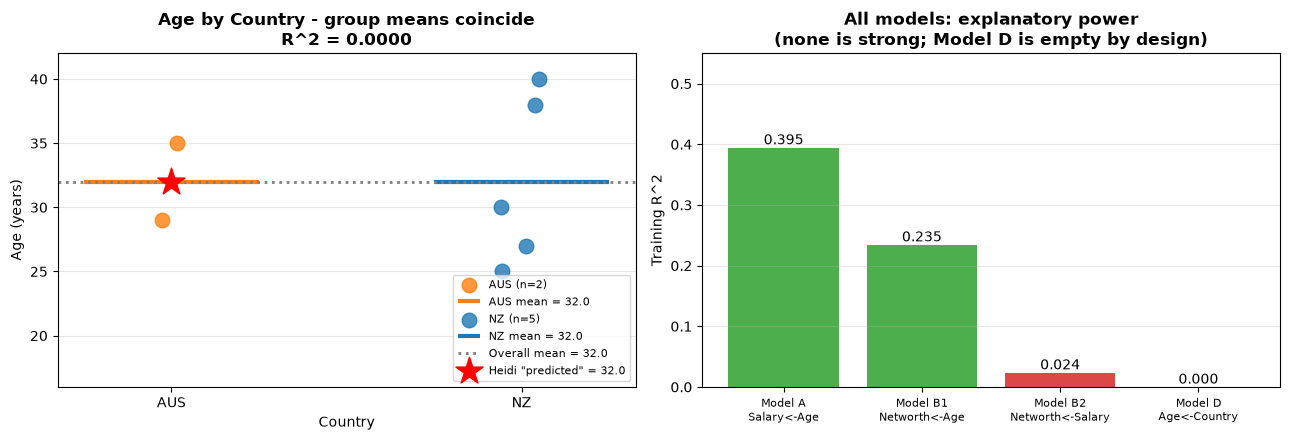

In [14]:
# Step 12 - Model D: Age <- Country (one-hot). Demonstration model - expected to fail.
print("MODEL D: Predicting Age from Country  [DEMONSTRATION - NOT A TRUSTED MODEL]")
print("=" * 72)

sub_d = df_clean[['Age', 'Country']].dropna()
print(f"Training rows (Age and Country both known): n = {len(sub_d)}")
print("\nAge distribution by country:")
grp = sub_d.groupby('Country')['Age'].agg(['count', 'mean', 'std', 'min', 'max'])
print(grp.to_string())

# One-hot encode. drop_first avoids the dummy-variable trap (perfect collinearity with intercept).
X_d = pd.get_dummies(sub_d['Country'], prefix='Country', drop_first=True).astype(float)
y_d = sub_d['Age'].values
print(f"\nEncoded predictor columns: {list(X_d.columns)}  (baseline category = AUS, in the intercept)")

model_d = LinearRegression().fit(X_d, y_d)
y_pred_d = model_d.predict(X_d)
r2_d = r2_score(y_d, y_pred_d)
rmse_d = float(np.sqrt(mean_squared_error(y_d, y_pred_d)))
baseline_d = loocv_mean_baseline(y_d)

print(f"\nFitted model : Age = {model_d.intercept_:.2f} + "
      + " + ".join(f"{c:.4f} * {n}" for c, n in zip(model_d.coef_, X_d.columns)))
print(f"R^2          : {r2_d:.4f}")
print(f"Train RMSE   : {rmse_d:.2f} years")
print(f"Mean-only RMSE (same data, no predictor): {y_d.std(ddof=0):.2f} years")

# Predict Heidi: her country is AUS = the baseline category, so all dummies are 0
heidi_row = df_clean[df_clean['Name'] == 'Heidi'].iloc[0]
X_heidi = pd.DataFrame([{col: 1.0 if col == f"Country_{heidi_row['Country']}" else 0.0
                         for col in X_d.columns}])
heidi_age_pred = float(model_d.predict(X_heidi)[0])

print("\n" + "-" * 72)
print(f"PREDICTION FOR HEIDI (Country = {heidi_row['Country']}): Age = {heidi_age_pred:.1f} years")
print("-" * 72)

print("\nWHY THIS RESULT IS THE EXPECTED ONE:")
print(f"  Mean age in NZ  : {grp.loc['NZ', 'mean']:.1f} years (n = {int(grp.loc['NZ', 'count'])})")
print(f"  Mean age in AUS : {grp.loc['AUS', 'mean']:.1f} years (n = {int(grp.loc['AUS', 'count'])})")
print("  The two group means are IDENTICAL. A one-hot regression on a single categorical predictor")
print("  can do exactly one thing: predict each group's mean. When the group means are the same,")
print("  the fitted slope is ~0, the model collapses to 'always predict the overall mean', and")
print(f"  R^2 = {r2_d:.4f} exactly.")
print("\n  So the 'prediction' for Heidi is not a prediction at all - it is the dataset average age")
print("  wearing a regression equation as a disguise. Knowing Heidi lives in AUS told us NOTHING.")
print("  This is a correct and useful finding: it QUANTIFIES the absence of a relationship.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {'NZ': '#1f77b4', 'AUS': '#ff7f0e'}
# Seeded so the figure is byte-reproducible across runs. The jitter only spreads points
# horizontally within their country so they do not overlap - it changes no value.
jitter_rng = np.random.default_rng(0)
for i, (c, g) in enumerate(sub_d.groupby('Country')):
    axes[0].scatter(np.full(len(g), i) + jitter_rng.uniform(-0.06, 0.06, len(g)), g['Age'],
                    s=110, alpha=0.8, color=colors[c], label=f'{c} (n={len(g)})', zorder=3)
    axes[0].hlines(g['Age'].mean(), i - 0.25, i + 0.25, color=colors[c], lw=3,
                   label=f'{c} mean = {g["Age"].mean():.1f}')
axes[0].axhline(y_d.mean(), color='grey', ls=':', lw=2, label=f'Overall mean = {y_d.mean():.1f}')
axes[0].scatter([0], [heidi_age_pred], marker='*', s=420, color='red', zorder=5,
                label=f'Heidi "predicted" = {heidi_age_pred:.1f}')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(sorted(sub_d['Country'].unique()))
axes[0].set_xlabel('Country'); axes[0].set_ylabel('Age (years)')
axes[0].set_title(f'Age by Country - group means coincide\nR^2 = {r2_d:.4f}',
                  fontsize=12, fontweight='bold')
axes[0].set_ylim(y_d.min() - 9, y_d.max() + 2)  # headroom so the legend clears the data
axes[0].legend(fontsize=8, loc='lower right'); axes[0].grid(alpha=0.3, axis='y')

names = ['Model A\nSalary<-Age', 'Model B1\nNetworth<-Age', 'Model B2\nNetworth<-Salary', 'Model D\nAge<-Country']
r2s = [res_salary['linear']['r2'], res_nw_age['linear']['r2'], res_nw_sal['linear']['r2'], r2_d]
bars = axes[1].bar(names, r2s, color=['#2ca02c', '#2ca02c', '#d62728', '#d62728'], alpha=0.85)
for b, v in zip(bars, r2s):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Training R^2'); axes[1].set_ylim(0, 0.55)
axes[1].set_title('All models: explanatory power\n(none is strong; Model D is empty by design)',
                  fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', labelsize=8); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../figures/model_d_age_from_country.png', dpi=100, bbox_inches='tight')
plt.show()

In [15]:
# Step 13 - Impute missing values, tagging every filled cell with its confidence
print("IMPUTATION WITH CONFIDENCE TAGGING")
print("=" * 72)

df_final = df_clean.copy()
df_final['age_is_low_confidence_imputation'] = False
df_final['networth_is_imputed'] = False
df_final['salary_is_imputed'] = False
provenance = []

# --- Net worth <- Age (linear), the one genuine regression imputation: David only
nw_rows = feasibility[('Net worth', 'Age')]
print(f"\n1. NET WORTH <- AGE (linear, R^2 = {res_nw_age['linear']['r2']:.3f})")
if nw_rows:
    best_nw = res_nw_age['linear']
    for idx in nw_rows:
        age_val = df_final.loc[idx, 'Age']
        # Round ONCE, here, so the prediction file and the joined file cannot disagree
        pred = round(float(predict_with(best_nw['model'], best_nw['poly'],
                                        np.array([[age_val]]))[0]), 2)
        df_final.loc[idx, 'Net worth'] = pred
        df_final.loc[idx, 'networth_is_imputed'] = True
        provenance.append((df_final.loc[idx, 'ID'], df_final.loc[idx, 'Name'], 'Net worth', pred,
                           'Net worth <- Age (linear)',
                           'LOW - and see Step 17b: not statistically significant, biased low here'))
        print(f"   {df_final.loc[idx, 'Name']}: Age {age_val:.0f} -> Net worth ${pred:,.0f}")
    print("   Tagged: networth_is_imputed = True")
    print("   NOTE: Step 17b tests this model with a permutation test and finds it is NOT")
    print("   statistically significant, and that it under-predicts at the high end of the Age")
    print("   range - which is exactly where David sits. Treat this value as directionally")
    print("   suspect, not merely imprecise.")
else:
    print("   No usable rows.")

# --- Salary <- Age: nothing left to fill, the merge already handled it
sal_rows = feasibility[('Salary', 'Age')]
print(f"\n2. SALARY <- AGE (linear, R^2 = {res_salary['linear']['r2']:.3f})")
print(f"   Usable rows: {len(sal_rows)}")
print("   Nothing to impute. Bob's missing Salary was recovered by MERGING his split record")
print("   in Step 5b, using his own recorded value of 60,000 rather than a predicted one.")
print("   Heidi's Salary stays MISSING: predicting it requires an Age she does not have.")

# --- Age <- Country: demonstration only, tagged as untrustworthy
print(f"\n3. AGE <- COUNTRY (demonstration model, R^2 = {r2_d:.4f})")
heidi_idx = df_final.index[df_final['Name'] == 'Heidi'][0]
df_final.loc[heidi_idx, 'Age'] = heidi_age_pred
df_final.loc[heidi_idx, 'age_is_low_confidence_imputation'] = True
provenance.append((df_final.loc[heidi_idx, 'ID'], 'Heidi', 'Age', heidi_age_pred,
                   'Age <- Country (one-hot)',
                   'NONE - R^2 = 0.0000, this is the dataset mean, not a prediction'))
print(f"   Heidi: Country AUS -> Age {heidi_age_pred:.1f}")
print("   Tagged: age_is_low_confidence_imputation = True")
print("   This value exists so the pipeline runs end to end. It carries NO statistical support")
print("   and must not be used as if it were an observation like Alice's Age = 25.")

# --- Explicit refusal: do not chain imputations
print("\n4. DELIBERATELY NOT DONE - CHAINED IMPUTATION")
print("   Heidi now has an Age value, so Salary <- Age and Net worth <- Age would technically run.")
print("   We do NOT run them. Her Age is a placeholder with R^2 = 0, so feeding it into another")
print("   weak model would launder a non-prediction into two more numbers that look like data.")
print("   Errors compound; confidence tags do not. Heidi's Salary and Net worth stay MISSING.")

print("\n" + "=" * 72)
print("IMPUTATION PROVENANCE")
print("=" * 72)
prov_df = pd.DataFrame(provenance, columns=['ID', 'Person', 'Field', 'Imputed value',
                                            'Model', 'Confidence'])
_display = prov_df.copy()
_display['Imputed value'] = _display['Imputed value'].map(lambda v: f"{v:,.2f}")
print(_display.to_string(index=False))

print("\n" + "=" * 72)
print("FINAL DATASET (9 people, with confidence flags)")
print("=" * 72)
print(df_final[['ID', 'Name', 'Age', 'age_is_low_confidence_imputation', 'Salary',
                'Net worth', 'networth_is_imputed', 'Country', 'Join Date']].to_string(index=False))

print("\nUNUSABLE CELLS AT EACH STAGE OF THE PIPELINE:")
summary = pd.DataFrame({
    'Blank in raw CSV': df.isnull().sum(),
    'After cleaning (10 rows)': df_clean_premerge.isnull().sum(),
    'After merge (9 rows)': df_clean.isnull().sum(),
    'After imputation': df_final[df.columns].isnull().sum(),
})
print(summary.to_string())
print("\n  Read the first two columns carefully - cleaning made 'Join Date' look WORSE (1 -> 2).")
print("  That is correct. The raw file recorded Eve's join date as '2019-13-01'. It is not blank,")
print("  so it does not count as missing in column 1, but there is no month 13, so parsing")
print("  converts it to NaT. Cleaning did not lose data: it exposed a value that was never valid.")
print("  The same applies in reverse to Age and Salary - 'thirty-eight' and 'sixty five thousand'")
print("  are non-blank in column 1 and become usable numbers by column 2.")

print("\nWHY THE TAGS MATTER - summary statistics computed both ways:")
obs_age = df_final.loc[~df_final['age_is_low_confidence_imputation'], 'Age']
all_age = df_final['Age']
print(f"  Mean Age, observed values only     : {obs_age.mean():.2f} years (n = {obs_age.count()})")
print(f"  Mean Age, including imputed value  : {all_age.mean():.2f} years (n = {all_age.count()})")
print(f"  Std  Age, observed values only     : {obs_age.std():.2f}")
print(f"  Std  Age, including imputed value  : {all_age.std():.2f}")
print("  The mean barely moves (the imputed value IS close to the mean), but the standard deviation")
print("  shrinks - imputing with a central value fakes agreement that the data does not contain.")
print("  RECOMMENDATION: exclude tagged rows from any descriptive statistic or downstream model.")

# --- Persist THREE artifacts, because they are reproducible from different inputs ---
from pathlib import Path
Path('../models').mkdir(exist_ok=True)

# 1. Canonical cleaned data: OBSERVED VALUES ONLY. Gaps stay NaN. Depends on the raw
#    CSV and the cleaning code, nothing else - so it does not change when a model does.
df_clean.to_csv('../data/processed/W3Act1-2_cleaned.csv', index=False)

# 2. Model output: one row per imputed cell, carrying the model and confidence that
#    produced it. Depends on a fitted model, so it belongs with models/, not data/.
prov_df.to_csv('../models/predictions.csv', index=False)

# 3. Convenience join of 1 and 2, for code that wants a single table. Derived - if it
#    ever disagrees with the two files above, they are right and this one is stale.
df_final.to_csv('../data/processed/W3Act1-2_cleaned_imputed.csv', index=False)

print("\n" + "=" * 72)
print("ARTIFACTS WRITTEN")
print("=" * 72)
print("  data/processed/W3Act1-2_cleaned.csv       observed values only, gaps left as NaN")
print("  models/predictions.csv                      the 2 imputed cells + model + confidence")
print("  data/processed/W3Act1-2_cleaned_imputed.csv the join of the two (convenience only)")
print("""
WHY THESE ARE SEPARATE FILES, NOT ONE:
  The cleaned table and the predictions have different provenance. The cleaned file is a
  deterministic function of the raw CSV and the cleaning code. The predictions depend on a
  fitted model, a chosen predictor and a seed - change the model and only that file should
  change. Storing them together makes it impossible to tell, from the file alone, which
  stage any number came from.

  It also removes a footgun. In the joined file, Alice's observed Age = 25 and Heidi's
  fabricated Age = 32.0 sit in the same column, separated only by a flag that the reader
  has to know to filter on. Anyone calling df['Age'].mean() on it silently folds in a value
  with R^2 = 0.0000. The observed-only file cannot do that to you.

  USE data/processed/W3Act1-2_cleaned.csv for descriptive statistics and any downstream
  model. Reach for the joined file only when you need a single dense table and have read
  the flags.""")

IMPUTATION WITH CONFIDENCE TAGGING

1. NET WORTH <- AGE (linear, R^2 = 0.235)
   David: Age 38 -> Net worth $47,885
   Tagged: networth_is_imputed = True
   NOTE: Step 17b tests this model with a permutation test and finds it is NOT
   statistically significant, and that it under-predicts at the high end of the Age
   range - which is exactly where David sits. Treat this value as directionally
   suspect, not merely imprecise.

2. SALARY <- AGE (linear, R^2 = 0.395)
   Usable rows: 0
   Nothing to impute. Bob's missing Salary was recovered by MERGING his split record
   in Step 5b, using his own recorded value of 60,000 rather than a predicted one.
   Heidi's Salary stays MISSING: predicting it requires an Age she does not have.

3. AGE <- COUNTRY (demonstration model, R^2 = 0.0000)
   Heidi: Country AUS -> Age 32.0
   Tagged: age_is_low_confidence_imputation = True
   This value exists so the pipeline runs end to end. It carries NO statistical support
   and must not be used as if it 

## Step 14 - Honest validation: Bob as a held-out test case

Every R^2 reported so far was computed on data the model had already seen, and LOOCV, while better,
still recycles the same 8 people. Bob offers something rarer: a **genuinely held-out person**.

The protocol:

1. Remove Bob **entirely** from the dataset - both of his original partial rows are already fused
   into one record, and that whole record is withheld.
2. Train `Salary <- Age` and `Net worth <- Age` on the remaining people only.
3. Predict Bob's Salary and Net worth from his Age alone.
4. Compare against his **actual recorded values** (Salary 60,000, Net worth 35,000), which the models
   never saw.

**Why the merge had to happen first:** before merging, Bob's two rows each held half his data. Had
both sat in the training set, any model would have been scored partly on information taken from Bob
himself - the answer would have leaked in through the second row. Merging first, then withholding
the single complete record, is what makes this a clean test.

This is the only true out-of-sample accuracy check this dataset permits - and it rests on exactly
**one** person.

HELD-OUT VALIDATION: BOB
Withheld person : Bob (ID 2)
  Actual Age       : 30
  Actual Salary    : $60,000   <- hidden from the models
  Actual Net worth : $35,000   <- hidden from the models

Training pool: 8 people (Bob's complete record fully removed)

------------------------------------------------------------------------
Salary <- Age   (trained on n = 7, Bob excluded)
  Linear       predicted $   62,527 | actual $   60,000 | error $   +2,527 (  4.2%)
  Poly deg 2   predicted $   61,455 | actual $   60,000 | error $   +1,455 (  2.4%)
  Mean-only    predicted $   63,000 | actual $   60,000 | error $   +3,000 (  5.0%)

------------------------------------------------------------------------
Net worth <- Age   (trained on n = 6, Bob excluded)
  Linear       predicted $   39,543 | actual $   35,000 | error $   +4,543 ( 13.0%)
  Poly deg 2   predicted $   38,050 | actual $   35,000 | error $   +3,050 (  8.7%)
  Mean-only    predicted $   39,167 | actual $   35,000 | error $   +4,167 (

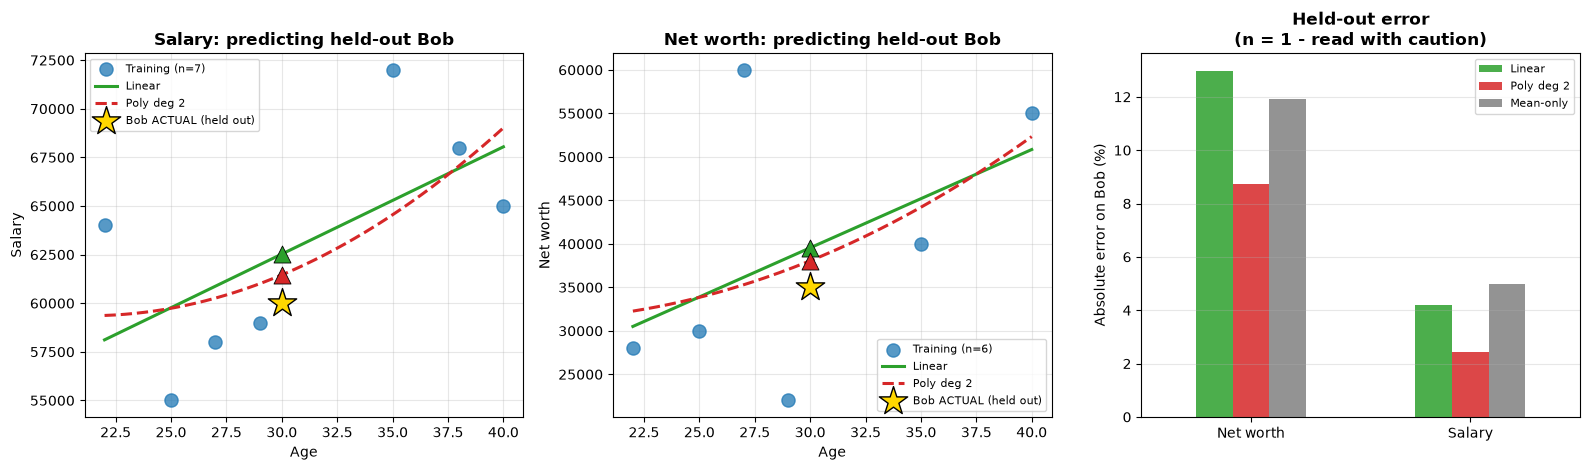


WHAT THIS TEST DOES AND DOES NOT ESTABLISH
  Errors on Bob range from 2.4% to 13.0%. Salary is predicted
  more accurately than Net worth, which matches the LOOCV ranking from Steps 9-10.

  NOTE THE CONTRADICTION: on this single point the POLYNOMIAL beats the linear model,
  while LOOCV across all 8 people preferred LINEAR. Both cannot be the general truth.
  A test set of n = 1 cannot discriminate between models - a single lucky point is not
  evidence of a better model any more than a rising training R^2 is. The LOOCV result,
  which averages over every person in turn, is the more reliable of the two.

  What this test DOES establish: the pipeline produces plausible values on data it has
  never seen, and it is not catastrophically broken.
  What it does NOT establish: any usable estimate of accuracy. One person cannot
  validate a model, and this dataset cannot support a real train/test split.


In [16]:
# Step 14 - Held-out validation using Bob (excluded from training entirely)
print("HELD-OUT VALIDATION: BOB")
print("=" * 72)

bob = df_clean[df_clean['ID'] == 2].iloc[0]
train_pool = df_clean[df_clean['ID'] != 2]

print(f"Withheld person : {bob['Name']} (ID {int(bob['ID'])})")
print(f"  Actual Age       : {bob['Age']:.0f}")
print(f"  Actual Salary    : ${bob['Salary']:,.0f}   <- hidden from the models")
print(f"  Actual Net worth : ${bob['Net worth']:,.0f}   <- hidden from the models")
print(f"\nTraining pool: {len(train_pool)} people (Bob's complete record fully removed)")

held_out = []
for ycol in ['Salary', 'Net worth']:
    sub = train_pool[['Age', ycol]].dropna()
    Xt, yt = sub[['Age']].values, sub[ycol].values
    print(f"\n{'-' * 72}\n{ycol} <- Age   (trained on n = {len(sub)}, Bob excluded)")
    for degree in (1, 2):
        model, poly = build_model(Xt, yt, degree)
        pred = float(predict_with(model, poly, np.array([[bob['Age']]]))[0])
        actual = float(bob[ycol])
        err = pred - actual
        name = 'Linear' if degree == 1 else 'Poly deg 2'
        print(f"  {name:<12} predicted ${pred:>9,.0f} | actual ${actual:>9,.0f} | "
              f"error ${err:>+9,.0f} ({abs(err) / actual * 100:5.1f}%)")
        held_out.append({'target': ycol, 'model': name, 'pred': pred,
                         'actual': actual, 'err': err, 'pct': abs(err) / actual * 100})
    # Reference point: what would a no-predictor guess have scored?
    naive = float(yt.mean())
    print(f"  {'Mean-only':<12} predicted ${naive:>9,.0f} | actual ${float(bob[ycol]):>9,.0f} | "
          f"error ${naive - float(bob[ycol]):>+9,.0f} "
          f"({abs(naive - float(bob[ycol])) / float(bob[ycol]) * 100:5.1f}%)")
    held_out.append({'target': ycol, 'model': 'Mean-only', 'pred': naive, 'actual': float(bob[ycol]),
                     'err': naive - float(bob[ycol]),
                     'pct': abs(naive - float(bob[ycol])) / float(bob[ycol]) * 100})

ho = pd.DataFrame(held_out)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, ycol in zip(axes[:2], ['Salary', 'Net worth']):
    sub = train_pool[['Age', ycol]].dropna()
    Xt, yt = sub[['Age']].values, sub[ycol].values
    ax.scatter(Xt, yt, s=90, color='#1f77b4', alpha=0.75, zorder=3, label=f'Training (n={len(sub)})')
    grid = np.linspace(min(Xt.min(), bob['Age']), max(Xt.max(), bob['Age']), 200).reshape(-1, 1)
    for degree, col, ls in [(1, '#2ca02c', '-'), (2, '#d62728', '--')]:
        model, poly = build_model(Xt, yt, degree)
        ax.plot(grid, predict_with(model, poly, grid), color=col, ls=ls, lw=2.2,
                label='Linear' if degree == 1 else 'Poly deg 2')
        p = predict_with(model, poly, np.array([[bob['Age']]]))[0]
        ax.scatter([bob['Age']], [p], marker='^', s=150, color=col, zorder=5, edgecolor='k', lw=0.6)
    ax.scatter([bob['Age']], [bob[ycol]], marker='*', s=460, color='gold', edgecolor='k',
               lw=1.0, zorder=6, label=f"Bob ACTUAL (held out)")
    ax.set_xlabel('Age'); ax.set_ylabel(ycol)
    ax.set_title(f'{ycol}: predicting held-out Bob', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

piv = ho.pivot(index='target', columns='model', values='pct')[['Linear', 'Poly deg 2', 'Mean-only']]
piv.plot(kind='bar', ax=axes[2], color=['#2ca02c', '#d62728', 'grey'], alpha=0.85, rot=0)
axes[2].set_ylabel('Absolute error on Bob (%)'); axes[2].set_xlabel('')
axes[2].set_title('Held-out error\n(n = 1 - read with caution)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../figures/heldout_validation_bob.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n" + "=" * 72)
print("WHAT THIS TEST DOES AND DOES NOT ESTABLISH")
print("=" * 72)
best_row = ho.loc[ho['pct'].idxmin()]
print(f"  Errors on Bob range from {ho['pct'].min():.1f}% to {ho['pct'].max():.1f}%. Salary is predicted")
print(f"  more accurately than Net worth, which matches the LOOCV ranking from Steps 9-10.")
print("\n  NOTE THE CONTRADICTION: on this single point the POLYNOMIAL beats the linear model,")
print("  while LOOCV across all 8 people preferred LINEAR. Both cannot be the general truth.")
print("  A test set of n = 1 cannot discriminate between models - a single lucky point is not")
print("  evidence of a better model any more than a rising training R^2 is. The LOOCV result,")
print("  which averages over every person in turn, is the more reliable of the two.")
print("\n  What this test DOES establish: the pipeline produces plausible values on data it has")
print("  never seen, and it is not catastrophically broken.")
print("  What it does NOT establish: any usable estimate of accuracy. One person cannot")
print("  validate a model, and this dataset cannot support a real train/test split.")

# Part 4 - What a production pipeline would do differently

Parts 1-3 answered the assignment. This part answers the harder question behind it: **out of 12
broken cells, why could regression only fill one - and what would a working data scientist do about
it on a dataset too large to inspect by eye?**

The three diagnostics below are the ones that scale. Each is run on this 9-row dataset, where the
result can still be checked by hand - which is the whole point of practising on something small.

| Step | Technique | Question it answers |
|---|---|---|
| 15 | Missingness **pattern** analysis | *Which gaps are even reachable?* |
| 16 | Multivariate imputation (MICE / KNN) | *Does using every predictor at once rescue them?* |
| 17 | Systematic **masking validation** | *How wrong are our imputations, really?* |

MISSINGNESS PATTERN ANALYSIS

The usual summary - missingness RATE per column:
   Age          1/9 missing (11%)
   Salary       1/9 missing (11%)
   Net worth    2/9 missing (22%)

   This view is misleading on its own. 'Net worth is 22% missing' says nothing about
   whether those gaps are FILLABLE. That depends on the pattern, not the rate.

The useful summary - one line per row, classified by what it has LEFT to predict from:
------------------------------------------------------------------------
     Name              kind                missing        predictors_left
    Alice          COMPLETE                      - Age, Salary, Net worth
      Bob          COMPLETE                      - Age, Salary, Net worth
  Charlie          COMPLETE                      - Age, Salary, Net worth
    David ITEM non-response              Net worth            Age, Salary
      Eve          COMPLETE                      - Age, Salary, Net worth
(no name)          COMPLETE                      

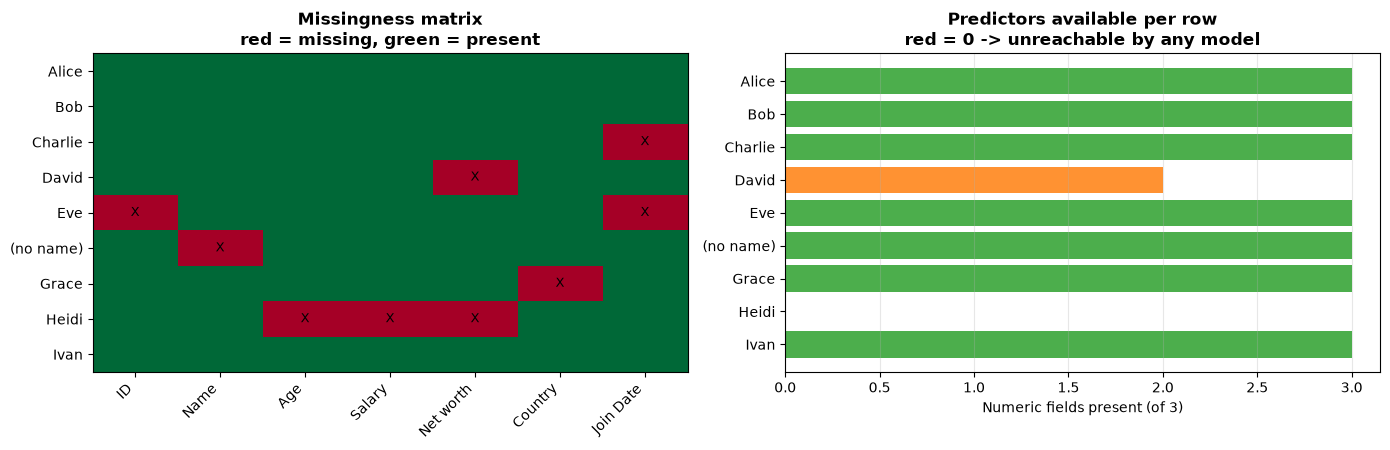

In [17]:
# Step 15 - Missingness PATTERN analysis (not missingness rate)
import warnings
print("MISSINGNESS PATTERN ANALYSIS")
print("=" * 72)

num_cols = ['Age', 'Salary', 'Net worth']
work = df_clean[num_cols].copy()   # merged, pre-imputation

print("\nThe usual summary - missingness RATE per column:")
for c in num_cols:
    print(f"   {c:<12} {work[c].isna().sum()}/{len(work)} missing ({work[c].isna().mean() * 100:.0f}%)")
print("\n   This view is misleading on its own. 'Net worth is 22% missing' says nothing about")
print("   whether those gaps are FILLABLE. That depends on the pattern, not the rate.\n")

print("The useful summary - one line per row, classified by what it has LEFT to predict from:")
print("-" * 72)
pattern = []
for i, r in work.iterrows():
    missing = [c for c in num_cols if pd.isna(r[c])]
    present = [c for c in num_cols if not pd.isna(r[c])]
    if not missing:
        kind = 'COMPLETE'
    elif not present:
        kind = 'UNIT non-response'      # whole record empty -> unreachable
    else:
        kind = 'ITEM non-response'      # a few fields -> reachable
    who = df_clean.loc[i, 'Name'] if pd.notna(df_clean.loc[i, 'Name']) else '(no name)'
    pattern.append({'Name': who, 'kind': kind,
                    'missing': ', '.join(missing) or '-',
                    'predictors_left': ', '.join(present) or 'NONE'})
pat = pd.DataFrame(pattern)
print(pat.to_string(index=False))

print("\n" + "-" * 72)
print("CLASSIFICATION SUMMARY:")
for k, g in pat.groupby('kind'):
    print(f"   {k:<20} {len(g)} row(s): {', '.join(str(n) for n in g['Name'])}")

print("""
WHY THIS IS THE DIAGNOSTIC THAT MATTERS:

  ITEM non-response (David) - a few fields missing, the rest of the row intact.
     The surviving fields carry information about the gap, so a model can exploit them.
     THIS IS IMPUTABLE.

  UNIT non-response (Heidi) - the record is essentially empty.
     There is no predictor to condition on. No algorithm can fix this, because the
     problem is an absence of information, not an absence of technique.
     THIS IS NOT IMPUTABLE - and no amount of model tuning will change that.

  So the answer to 'why only one cell?' is not about sample size or model choice:
  of the 4 numeric gaps left after merging, 3 belong to Heidi and have ZERO predictors.
  Exactly 1 gap was ever reachable, and we filled it.

  AT SCALE: this same split is computed with one groupby over a missingness mask. Column-level
  missing-value percentages are the wrong summary - a column that is 30% missing is trivial when
  the gaps are scattered across otherwise-complete rows, and fatal when they are concentrated in
  rows missing everything else. Identical percentage, opposite outcome. (See the `missingno`
  library: msno.matrix() and msno.heatmap() draw exactly this picture.)""")

# Visual: the missingness matrix, the way missingno would draw it
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
mask = df_clean[['ID', 'Name', 'Age', 'Salary', 'Net worth', 'Country', 'Join Date']].isna()
axes[0].imshow(mask.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
axes[0].set_xticks(range(mask.shape[1])); axes[0].set_xticklabels(mask.columns, rotation=45, ha='right')
axes[0].set_yticks(range(len(df_clean)))
axes[0].set_yticklabels([f"{n}" for n in df_clean['Name'].fillna('(no name)')])
axes[0].set_title('Missingness matrix\nred = missing, green = present', fontsize=12, fontweight='bold')
for i in range(mask.shape[0]):
    for j in range(mask.shape[1]):
        axes[0].text(j, i, 'X' if mask.values[i, j] else '', ha='center', va='center', fontsize=9)

n_pred = [len([c for c in num_cols if not pd.isna(df_clean.loc[i, c])]) for i in df_clean.index]
cols = ['#2ca02c' if v == 3 else ('#ff7f0e' if v > 0 else '#d62728') for v in n_pred]
axes[1].barh(range(len(df_clean)), n_pred, color=cols, alpha=0.85)
axes[1].set_yticks(range(len(df_clean)))
axes[1].set_yticklabels([f"{n}" for n in df_clean['Name'].fillna('(no name)')])
axes[1].invert_yaxis()
axes[1].set_xlabel('Numeric fields present (of 3)')
axes[1].set_title('Predictors available per row\nred = 0 -> unreachable by any model',
                  fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.savefig('../figures/step15_missingness_pattern.png', dpi=100, bbox_inches='tight')
plt.show()

### Reading Step 15

Heidi's bar is at **zero**. That single fact explains the entire yield of Part 3.

The distinction between *item* and *unit* non-response is the one to carry into large datasets,
because it decides the strategy before any model is chosen:

- **Item non-response** -> impute, then validate (Steps 16-17).
- **Unit non-response** -> **drop the row**, or flag it and keep it out of anything that assumes
  observed data. Dropping Heidi would have been a perfectly professional answer.

Also worth naming: **why** a value is missing determines whether imputation is even valid
(Rubin's taxonomy).

- **MCAR** - missing completely at random. Imputation is safe.
- **MAR** - missingness is explainable by *other* columns. Imputation is valid, and this is the case
  every method below assumes.
- **MNAR** - missing *because of its own value*, e.g. high earners declining to state income.
  **Every technique in this notebook breaks under MNAR, and no diagnostic can detect it.**
  Only domain knowledge can. With 9 rows and no collection metadata, we cannot tell which regime
  this dataset is in - which is itself a limitation worth stating.

MULTIVARIATE IMPUTATION vs OUR UNIVARIATE MODELS
Our Part 3 models used ONE predictor at a time. MICE (IterativeImputer) fills every gap
using ALL other columns, cycling until the values stabilise. It is the standard tool.

Column means of the OBSERVED data (remember these numbers):
   Age = 30.75 | Salary = 62,625.00 | Net worth = 38,571.43

------------------------------------------------------------------------
WHAT EACH METHOD PRODUCED FOR THE GAPS
------------------------------------------------------------------------
Person     Field Ours (Part 3)   MICE    KNN Column mean MICE == mean?
 David Net worth        47,885 38,576 41,000      38,571           YES
 Heidi       Age            32     31     31          31           YES
 Heidi    Salary       REFUSED 62,625 62,625      62,625           YES
 Heidi Net worth       REFUSED 38,572 38,571      38,571           YES

TWO LESSONS, BOTH IMPORTANT:

1. MICE FILLED HEIDI WITHOUT COMPLAINT - and the values it produced ARE the column m

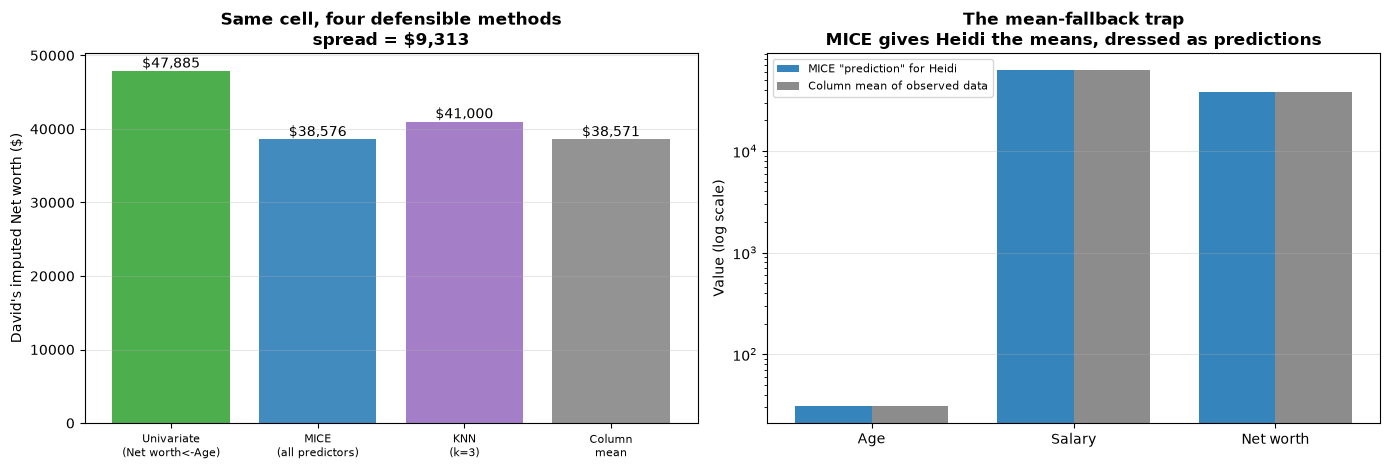

In [18]:
# Step 16 - Multivariate imputation (MICE / KNN): does using ALL predictors rescue the gaps?
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  (required to unlock the import)
from sklearn.impute import IterativeImputer, KNNImputer

print("MULTIVARIATE IMPUTATION vs OUR UNIVARIATE MODELS")
print("=" * 72)
print("Our Part 3 models used ONE predictor at a time. MICE (IterativeImputer) fills every gap")
print("using ALL other columns, cycling until the values stabilise. It is the standard tool.\n")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    mice_vals = IterativeImputer(random_state=0, max_iter=50).fit_transform(work)
    knn_vals = KNNImputer(n_neighbors=3).fit_transform(work)
mice = pd.DataFrame(mice_vals, columns=num_cols, index=work.index)
knn = pd.DataFrame(knn_vals, columns=num_cols, index=work.index)

col_means = work.mean()
print("Column means of the OBSERVED data (remember these numbers):")
print("   " + " | ".join(f"{c} = {col_means[c]:,.2f}" for c in num_cols))

print("\n" + "-" * 72)
print("WHAT EACH METHOD PRODUCED FOR THE GAPS")
print("-" * 72)
rows = []
for i in work.index:
    for c in num_cols:
        if pd.isna(work.loc[i, c]):
            ours = df_final.loc[i, c] if not pd.isna(df_final.loc[i, c]) else np.nan
            rows.append({'Person': df_clean.loc[i, 'Name'], 'Field': c,
                         'Ours (Part 3)': f"{ours:,.0f}" if not pd.isna(ours) else 'REFUSED',
                         'MICE': f"{mice.loc[i, c]:,.0f}", 'KNN': f"{knn.loc[i, c]:,.0f}",
                         'Column mean': f"{col_means[c]:,.0f}",
                         'MICE == mean?': 'YES' if abs(mice.loc[i, c] - col_means[c]) < 0.02 * abs(col_means[c]) else 'no'})
comp = pd.DataFrame(rows)
print(comp.to_string(index=False))

print("""
TWO LESSONS, BOTH IMPORTANT:

1. MICE FILLED HEIDI WITHOUT COMPLAINT - and the values it produced ARE the column means.
   Heidi has no observed numeric field, so there is nothing for MICE to condition on. It does
   not raise an error or return NaN; it quietly falls back to the average and returns it
   formatted exactly like a real prediction. This is the most dangerous failure mode in
   imputation: THE SOPHISTICATED TOOL DOES NOT REFUSE, IT DISGUISES.
   Our pipeline refusing those cells in Step 13 was worth more than these three numbers.

2. LOOK AT DAVID'S ROW TOO - MICE landed on the column mean for him as well.
   David is NOT an empty record: he has both Age and Salary. MICE had real predictors to work
   with and still came back with the average, because the conditional relationships are so weak
   (R^2 0.24 and 0.02) that the fitted model has almost nothing to add to the intercept.
   That is MICE being appropriately conservative - and it makes our univariate figure of
   47,885 the outlier among the four methods, not the consensus.

3. THE METHODS DISAGREE WIDELY ON THE SAME CELL - and none of them is wrong.
   The data simply does not pin the value down. That spread IS the uncertainty, and reporting
   a single imputed number throws it away. In production you would run MULTIPLE imputation:
   generate m datasets (typically 5-20), run the analysis on each, and pool the results so
   confidence intervals absorb the imputation uncertainty instead of ignoring it.""")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
david_i = df_clean.index[df_clean['Name'] == 'David'][0]
methods = ['Univariate\n(Net worth<-Age)', 'MICE\n(all predictors)', 'KNN\n(k=3)', 'Column\nmean']
vals = [df_final.loc[david_i, 'Net worth'], mice.loc[david_i, 'Net worth'],
        knn.loc[david_i, 'Net worth'], col_means['Net worth']]
bars = axes[0].bar(methods, vals, color=['#2ca02c', '#1f77b4', '#9467bd', 'grey'], alpha=0.85)
for b, v in zip(bars, vals):
    axes[0].text(b.get_x() + b.get_width() / 2, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel("David's imputed Net worth ($)")
axes[0].set_title(f"Same cell, four defensible methods\nspread = ${max(vals) - min(vals):,.0f}",
                  fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=8); axes[0].grid(alpha=0.3, axis='y')

heidi_i = df_clean.index[df_clean['Name'] == 'Heidi'][0]
x = np.arange(len(num_cols)); wbar = 0.38
axes[1].bar(x - wbar / 2, [mice.loc[heidi_i, c] for c in num_cols], wbar,
            label='MICE "prediction" for Heidi', color='#1f77b4', alpha=0.9)
axes[1].bar(x + wbar / 2, [col_means[c] for c in num_cols], wbar,
            label='Column mean of observed data', color='grey', alpha=0.9)
axes[1].set_xticks(x); axes[1].set_xticklabels(num_cols)
axes[1].set_yscale('log'); axes[1].set_ylabel('Value (log scale)')
axes[1].set_title('The mean-fallback trap\nMICE gives Heidi the means, dressed as predictions',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('../figures/step16_mice_vs_univariate.png', dpi=100, bbox_inches='tight')
plt.show()

### Reading Step 16

The bars for Heidi are the same height. MICE did not predict her age, salary or net worth - it
returned the column averages and formatted them like predictions.

**This is the lesson that does not scale down from a textbook, only up from a small dataset.** At
n = 9 you can spot it by comparing three numbers to three means. At n = 9,000,000 the identical
thing happens to every empty row in your table and nothing in the output will tell you. You have to
already know to check - which is why the row-level diagnostic in Step 15 comes *first*, and why our
Step 13 refusal was the correct engineering decision rather than a missed opportunity.

**The rule:** an imputation method's willingness to return a value is not evidence that the value
means anything. Check what a method does with a row that has no information *before* trusting what
it does with rows that do.

MASKING VALIDATION
Step 14 tested on ONE person (Bob). But EVERY known value is a potential test case:
hide it, predict it, compare against the truth, put it back. Here is that done exhaustively.

           Model    Person Actual Predicted Error % Mean-only err %  Model wins
   Salary <- Age     Alice 55,000    60,822    10.6            15.8        True
   Salary <- Age       Bob 60,000    62,527     4.2             5.0        True
   Salary <- Age   Charlie 72,000    63,368    12.0            14.9        True
   Salary <- Age     David 68,000    66,074     2.8             9.0        True
   Salary <- Age       Eve 59,000    62,064     5.2             7.0        True
   Salary <- Age (no name) 65,000    69,865     7.5             4.2       False
   Salary <- Age     Grace 64,000    53,653    16.2             2.5       False
   Salary <- Age      Ivan 58,000    61,067     5.3             9.1        True
Net worth <- Age     Alice 30,000    34,319    14.4            33.3        True
Net

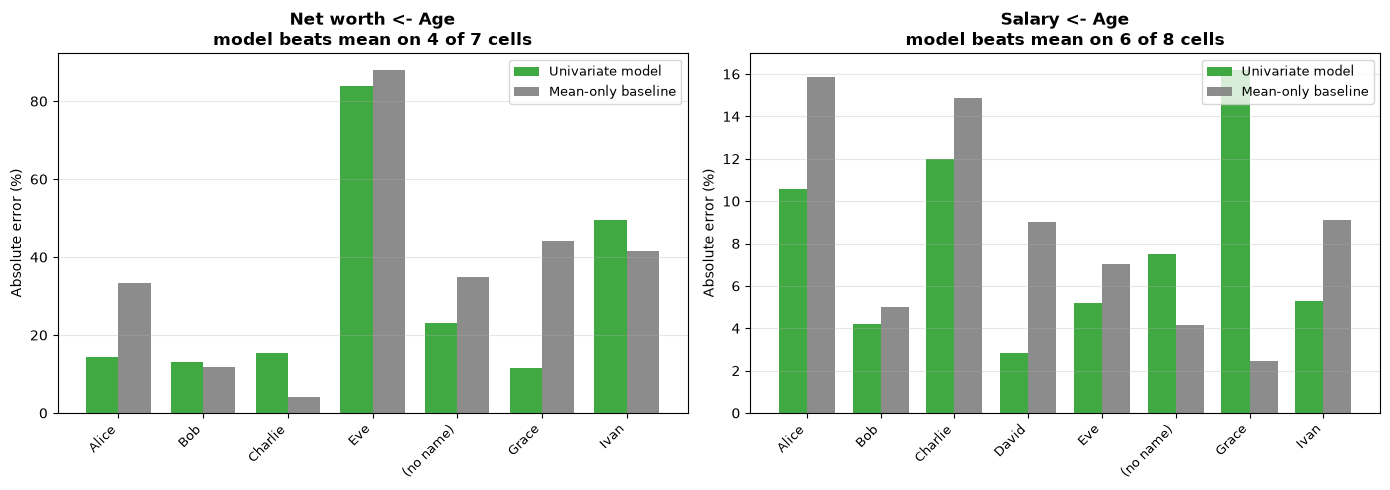

In [19]:
# Step 17 - Systematic masking validation: turn 1 test case into as many as the data allows
print("MASKING VALIDATION")
print("=" * 72)
print("Step 14 tested on ONE person (Bob). But EVERY known value is a potential test case:")
print("hide it, predict it, compare against the truth, put it back. Here is that done exhaustively.\n")

mask_rows = []
for target, predictor in [('Salary', 'Age'), ('Net worth', 'Age')]:
    sub = work[[predictor, target]].dropna()
    for i in sub.index:
        train = sub.drop(index=i)
        mdl = LinearRegression().fit(train[[predictor]], train[target])
        pred = float(mdl.predict(pd.DataFrame({predictor: [sub.loc[i, predictor]]}))[0])
        actual = float(sub.loc[i, target])
        naive = float(train[target].mean())
        who = df_clean.loc[i, 'Name'] if pd.notna(df_clean.loc[i, 'Name']) else '(no name)'
        mask_rows.append({'Model': f'{target} <- {predictor}', 'Person': who,
                          'Actual': actual, 'Predicted': pred, 'Error %': abs(pred - actual) / actual * 100,
                          'Mean-only err %': abs(naive - actual) / actual * 100,
                          'Model wins': abs(pred - actual) < abs(naive - actual)})
mk = pd.DataFrame(mask_rows)
show = mk.copy()
for c in ['Actual', 'Predicted']:
    show[c] = show[c].map(lambda v: f"{v:,.0f}")
for c in ['Error %', 'Mean-only err %']:
    show[c] = show[c].map(lambda v: f"{v:.1f}")
print(show.to_string(index=False))

print("\n" + "=" * 72)
print("SUMMARY - and how it compares to the single-Bob test in Step 14")
print("=" * 72)
print(f"{'Model':<22}{'Tests':>7}{'Mean err':>11}{'Median':>9}{'Worst':>9}{'Beats mean':>13}")
print("-" * 72)
for name, g in mk.groupby('Model'):
    wins = f"{int(g['Model wins'].sum())} of {len(g)}"
    print(f"{name:<22}{len(g):>7}{g['Error %'].mean():>10.1f}%{g['Error %'].median():>8.1f}%"
          f"{g['Error %'].max():>8.1f}%{wins:>13}")

bob_nw = mk[(mk['Model'] == 'Net worth <- Age') & (mk['Person'] == 'Bob')]['Error %'].iloc[0]
nw = mk[mk['Model'] == 'Net worth <- Age']
print(f"""
WHY THIS CHANGES THE CONCLUSION:

  Step 14 tested Net worth on Bob alone and got {bob_nw:.1f}% error - which looked tolerable.
  Across all {len(nw)} masked cells the average is {nw['Error %'].mean():.1f}%, the worst case is
  {nw['Error %'].max():.1f}% (Eve), and the model beats a plain average on only
  {int(nw['Model wins'].sum())} of {len(nw)} cells - a coin flip.

  That model is not weak, it is UNUSABLE, and only systematic masking exposed it. A single
  test point told us the opposite. This is the concrete cost of validating on n = 1.

  AT SCALE this is the technique that pays off most. Here it yields {len(mk)} test cases; on a real
  dataset it yields as many as you want, and you can stratify them - by segment, by region, by
  customer age - to answer the question that actually matters in production:
  NOT 'is our imputation accurate?' but 'WHICH ROWS do we impute badly?'
  Imputation error is almost never uniform, and the average hides the segments where it fails.""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, g) in zip(axes, mk.groupby('Model')):
    idx = np.arange(len(g)); wb = 0.38
    ax.bar(idx - wb / 2, g['Error %'], wb, label='Univariate model', color='#2ca02c', alpha=0.9)
    ax.bar(idx + wb / 2, g['Mean-only err %'], wb, label='Mean-only baseline', color='grey', alpha=0.9)
    ax.set_xticks(idx); ax.set_xticklabels(g['Person'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Absolute error (%)')
    ax.set_title(f"{name}\nmodel beats mean on {int(g['Model wins'].sum())} of {len(g)} cells",
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('../figures/step17_masking_validation.png', dpi=100, bbox_inches='tight')
plt.show()

### Reading Step 17

Green bar shorter than grey = the model earned its place on that cell. Grey shorter = we would have
been better off writing down the average.

For **Salary <- Age** the model wins most cells: a real, if modest, signal.
For **Net worth <- Age** it is close to a coin flip, with one catastrophic miss (Eve, ~84%). The
imputed value for David that Part 3 produced comes from *that* model - which is exactly why it was
tagged `networth_is_imputed` and why the tag is not decoration.

**This is the single most transferable technique in the notebook.** It needs no extra data, no
special library, and no assumptions - only the willingness to hide values you already have and check
whether you could have recovered them. It is how you earn the right to claim an imputation is
trustworthy, and it works identically on 9 rows and on 9 million.

## Step 17b - Which direction is the error, and is any of it decisive?

Steps 9-17 measured *how large* the errors are. Two questions remain, both raised by an independent
audit of this notebook and both verified from scratch before being adopted here:

1. **Which way do the errors point?** An average error of 30% could mean scattered noise, or it could
   mean a systematic bias. Those call for different responses.
2. **Is the signal statistically decisive?** Step 9 asserts that at `n = 8` these differences "are not
   decisive" but never tests it. An assertion is not a result.

For (2) the audit used bootstrap resampling and reported that `Net worth <- Age` beats the baseline in
53% of resamples. **That figure did not reproduce here** - an independent implementation gives 38%.
Bootstrapping is a poor fit for this question anyway: resampling with replacement duplicates rows, and
a duplicated row can land in both the training and the held-out side of a leave-one-out split, leaking
the answer and flattering the model.

A **permutation test** avoids that entirely. Shuffle the target so any real relationship is destroyed,
refit, and see how often pure noise produces a gain as large as the one we actually measured. That
fraction is a p-value, and no row is ever duplicated.

PART A - WHICH DIRECTION DOES THE ERROR POINT?

Net worth <- Age   corr(actual, signed error) = -0.93
  Person          Actual   Predicted  Signed error
  Eve             22,000      40,446       +18,446
  Grace           28,000      31,216        +3,216
  Alice           30,000      34,319        +4,319
  Bob             35,000      39,543        +4,543
  Charlie         40,000      46,164        +6,164
  (no name)       55,000      42,313       -12,687
  Ivan            60,000      30,298       -29,702

Salary <- Age   corr(actual, signed error) = -0.70
  Person          Actual   Predicted  Signed error
  Alice           55,000      60,822        +5,822
  Ivan            58,000      61,067        +3,067
  Eve             59,000      62,064        +3,064
  Bob             60,000      62,527        +2,527
  Grace           64,000      53,653       -10,347
  (no name)       65,000      69,865        +4,865
  David           68,000      66,074        -1,926
  Charlie         72,000      

Salary <- Age                  258     0.161       NOT significant


Net worth <- Age               802     0.176       NOT significant


Net worth <- Salary         -1,334     0.388       NOT significant

CONCLUSION: not one model reaches statistical significance. Even Salary <- Age - the only model
this notebook actually trusts - could be produced by chance roughly one time in six. Step 9's
claim that 'none of these differences are statistically decisive' was correct, and this is the
number that backs it up rather than asserting it.

Note what this does NOT say. A non-significant result is not proof that Age and Salary are
unrelated; it means 8 people cannot tell the difference between a real relationship and a lucky
one. Absence of evidence, not evidence of absence - the honest response is more data, not a
different model.


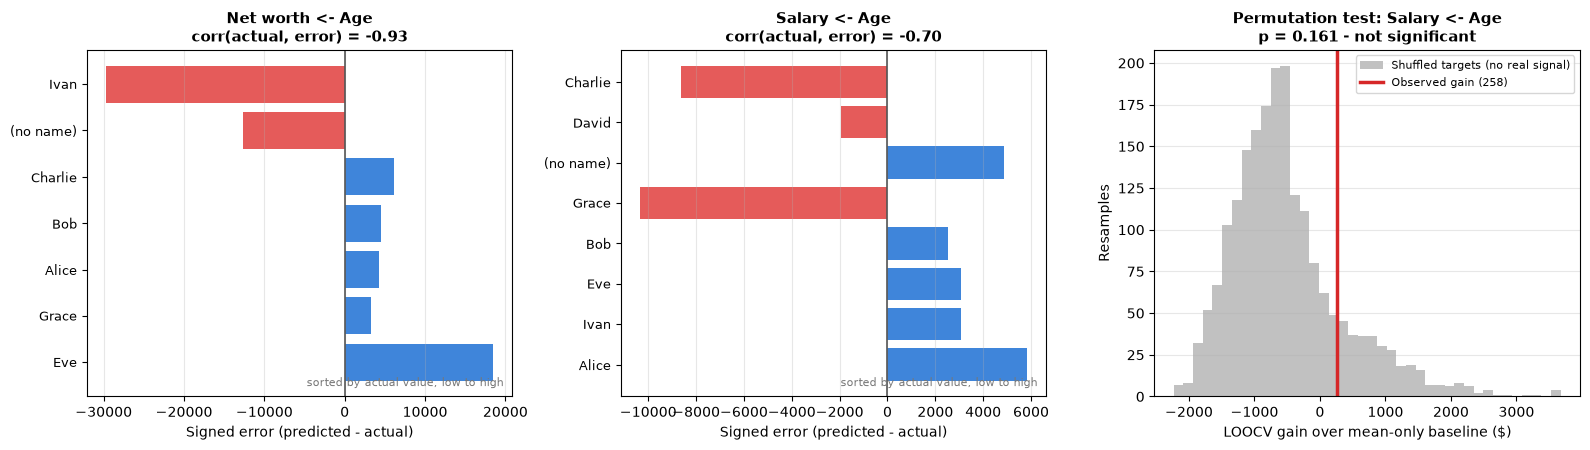

In [20]:
# Step 17b - Bias direction, and a permutation test of decisiveness
print("PART A - WHICH DIRECTION DOES THE ERROR POINT?")
print("=" * 72)

mk['Signed error'] = mk['Predicted'] - mk['Actual']
for name, g in mk.groupby('Model'):
    g = g.sort_values('Actual')
    corr = float(np.corrcoef(g['Actual'], g['Signed error'])[0, 1])
    print(f"\n{name}   corr(actual, signed error) = {corr:+.2f}")
    print(f"  {'Person':<12}{'Actual':>10}{'Predicted':>12}{'Signed error':>14}")
    for _, r in g.iterrows():
        print(f"  {r['Person']:<12}{r['Actual']:>10,.0f}{r['Predicted']:>12,.0f}{r['Signed error']:>+14,.0f}")

print("""
INTERPRETATION - this is regression to the mean, and it is structural.
  A strongly NEGATIVE correlation means the model over-predicts people with low actual values and
  under-predicts people with high ones. It is pulling every prediction toward the average, because a
  weak fit has a shallow slope - and a shallow slope IS a prediction close to the mean.

  The consequence is what matters: the model is least trustworthy for people at the extremes,
  which is usually exactly who a prediction is wanted for. An 'average error of 30%' sounds like
  scatter you could average away. It is not - it is a systematic squeeze, and it does not cancel.""")

print("\n\nPART B - IS ANY OF THIS STATISTICALLY DECISIVE?")
print("=" * 72)
print("Permutation test: shuffle the target 2,000 times, refit, and count how often random noise")
print("produces a gain over the mean-only baseline at least as large as the real one.\n")

perm = {}
print(f"{'Model':<22}{'Real gain':>12}{'p-value':>10}{'Verdict':>22}")
print("-" * 72)
for xcol, ycol in [('Age', 'Salary'), ('Age', 'Net worth'), ('Salary', 'Net worth')]:
    gain, nulls, p = permutation_test(work, xcol, ycol)
    perm[f'{ycol} <- {xcol}'] = (gain, nulls, p)
    verdict = 'significant' if p < 0.05 else 'NOT significant'
    print(f"{ycol + ' <- ' + xcol:<22}{gain:>12,.0f}{p:>10.3f}{verdict:>22}")

print("""
CONCLUSION: not one model reaches statistical significance. Even Salary <- Age - the only model
this notebook actually trusts - could be produced by chance roughly one time in six. Step 9's
claim that 'none of these differences are statistically decisive' was correct, and this is the
number that backs it up rather than asserting it.

Note what this does NOT say. A non-significant result is not proof that Age and Salary are
unrelated; it means 8 people cannot tell the difference between a real relationship and a lucky
one. Absence of evidence, not evidence of absence - the honest response is more data, not a
different model.""")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (name, g) in zip(axes, mk.groupby('Model')):
    g = g.sort_values('Actual')
    corr = float(np.corrcoef(g['Actual'], g['Signed error'])[0, 1])
    colors = ['#2a78d6' if v > 0 else '#e34948' for v in g['Signed error']]
    ax.barh(range(len(g)), g['Signed error'], color=colors, alpha=0.9)
    ax.set_yticks(range(len(g))); ax.set_yticklabels(g['Person'], fontsize=9)
    ax.axvline(0, color='#555', lw=1.2)
    ax.set_xlabel('Signed error (predicted - actual)')
    ax.set_title(f'{name}\ncorr(actual, error) = {corr:+.2f}', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3, axis='x')
    ax.text(0.98, 0.03, 'sorted by actual value, low to high', transform=ax.transAxes,
            ha='right', fontsize=8, color='#777')

gain, nulls, p = perm['Salary <- Age']
axes[2].clear()
axes[2].hist(nulls, bins=40, color='#bbb', alpha=0.9, label='Shuffled targets (no real signal)')
axes[2].axvline(gain, color='#d62728', lw=2.5, label=f'Observed gain ({gain:,.0f})')
axes[2].set_xlabel('LOOCV gain over mean-only baseline ($)')
axes[2].set_ylabel('Resamples')
axes[2].set_title(f'Permutation test: Salary <- Age\np = {p:.3f} - not significant',
                  fontsize=11, fontweight='bold')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('../figures/step17b_bias_and_significance.png', dpi=100, bbox_inches='tight')
plt.show()

### Reading Step 17b

**The red line sits inside the grey histogram.** That is the whole result: the gain our best model
achieves over simply predicting the average is well within the range that randomly shuffled data
produces. One time in six, noise does better.

Two things follow, and they pull in the same direction as everything else in this notebook:

- **The errors are biased, not random.** `Net worth <- Age` over-predicts Eve by \$18k and
  under-predicts Ivan by \$30k - the model squeezes everyone toward the mean. David, whose net worth
  we imputed, sits at the high end of the Age range, which is precisely where this model
  under-predicts. His imputed value is not merely uncertain; it is uncertain **with a known direction**.
- **Nothing here is statistically decisive.** Not the linear-vs-polynomial comparison, not
  `Net worth <- Age` beating its baseline by 5%, and not `Salary <- Age` either.

The audit's recommendation to strengthen David's tag is therefore adopted below - not on its
bootstrap figure, which did not reproduce, but on the permutation p-value, which was computed here.

## Step 18 - Limitations

Everything below is a genuine finding from this analysis, not a caveat added for form's sake.
At `n = 9` the honest conclusions are mostly negative ones, and they are worth more than an
optimistic number would be.

### 1. The dataset is too small for the claims regression normally supports

Nine people, of whom seven or eight have any given pair of fields complete. At that size a single
unusual person moves every statistic. **Ivan** (age 27, the highest net worth in the dataset,
on a below-average salary) single-handedly suppresses both Net-worth models. No amount of model
tuning fixes this; only more data would.

### 2. `Age <- Salary` was not built - a missing predictor, not a weak one

Heidi is the only person missing Age, and she is missing Salary too. Her Salary cannot be recovered
either, because that requires her Age: a **circular dependency**. The model would have fitted
cleanly and reported a respectable R^2 while being unable to fill a single cell. The check that
catches this is not a metric - it is the intersection of *"target missing"* and *"predictor present"*
(Step 11), which is empty.

### 3. `Age <- Country` was built anyway, and its failure is the result

Country was the only defensible predictor Heidi had. The model returns **R^2 = 0.0000**, because the
mean age in NZ and in AUS are both exactly 32.0 - a one-hot regression can only predict group means,
and identical group means collapse it into the overall average.

**This is the expected and correct outcome, not a failure of the code.** It was included to exercise
the pipeline end to end and to quantify the absence of a relationship rather than assume it. Heidi's
imputed age of 32.0 is the dataset mean wearing a regression equation as a disguise. It is flagged
`age_is_low_confidence_imputation = True` and should be excluded from any downstream statistic.

### 4. Nested R^2 comparisons cannot choose between linear and polynomial here

Adding `Age^2` to a model containing `Age` can never lower training R^2 - the linear model is the
polynomial with `b2 = 0`, so OLS can always match it and will edge past it by fitting noise. The
rise from 0.39 to 0.43 in Model A is arithmetic, not evidence.

Model B2 shows the one exception, and it is a numerical rather than a statistical one: R^2 *falls*
very slightly (0.0236 -> 0.0224) because `Salary^2` reaches 5.2 billion against `Salary`'s 72,000.
Five orders of magnitude between two columns makes the least-squares solve ill-conditioned, and the
fitted quadratic collapses toward a flat line. That is a warning about the fit, not a finding about
the data - and one more reason not to use a polynomial on a raw large-magnitude predictor.

The metrics that *can* discriminate both point the other way: **adjusted R^2 falls** and
**LOOCV RMSE worsens sharply** for every polynomial fitted here. The linear models are preferred
throughout - though at this sample size even that preference is tentative.

### 5. The models barely beat guessing

| Model | R^2 | LOOCV RMSE | Mean-only baseline | Verdict |
|---|---|---|---|---|
| Salary <- Age (linear) | 0.395 | 5,788 | 6,046 | Beats baseline by ~4% |
| Net worth <- Age (linear) | 0.235 | 14,497 | 15,299 | Beats baseline by ~5% |
| Net worth <- Salary (linear) | 0.024 | 16,633 | 15,299 | **Worse than the average** |
| Age <- Country | 0.000 | - | - | No relationship at all |

Only two models carry any signal, and both by a margin that 9 people cannot make significant.

The masking validation in **Step 17** sharpens this considerably. Per-cell, `Net worth <- Age`
beats a plain average on only **4 of 7** cells, with a mean absolute error of **30%** and a worst
case of **84%**. `Salary <- Age` wins **6 of 8** at a mean error of **8%**. So the ranking holds,
but the Net-worth model is worse than its LOOCV summary suggested - it is close to a coin flip, and
**David's imputed net worth inherits that.** The `networth_is_imputed` tag is doing real work.

Step 16 adds a second check on the same value: MICE and KNN, given every available predictor, both
returned approximately the **column mean** for David, while our univariate model returned 47,885.
Four defensible methods spanning $9,300 on one cell is the honest measure of how little the data
determines it.

### 6. Held-out validation rested on one person - now corrected

Bob was the only genuine out-of-sample test in Part 3, and n = 1 proves nothing. Note that the
polynomial beat the linear model *on Bob* while losing on LOOCV across everyone - a direct
demonstration that a single test point cannot rank models.

**Step 17 replaces that test properly**, masking all 15 known numeric cells in turn. It is worth
seeing how misleading the single test was: Bob suggested `Net worth <- Age` was accurate to 13%,
while the full picture is a 30% average. A single lucky test point flatters a model exactly the way
a rising training R^2 does.

### 7. Merging beat modelling

The one Salary a regression could have imputed was Bob's - and merging his split record recovered it
from his own recorded value instead. **Fixing the data structure removed the need for the model.**
This is the most transferable lesson in the notebook: check for split, duplicated, or malformed
records before reaching for an imputation model.

### 8. Fields left untouched, and why

- **Heidi's Salary and Net worth** stay missing. She has no usable predictor, and chaining them off
  her R^2 = 0 imputed Age would launder a non-prediction into two more numbers that look like data.
  Errors compound; confidence tags do not.
- **Grace's Country, Eve's ID, row 7's Name** - categorical or identifier fields. Regression does not
  apply, and with 9 rows there is no basis for a classifier.
- **Join Dates** (Charlie, Eve) are not modelled. Eve's raw value `2019-13-01` is almost certainly
  `13/01/2019` with the day and month transposed - recoverable by a **parsing rule**, not by
  regression. It was left as `NaT` rather than guessed, since the analysis does not depend on it.

### 10. What an independent audit found - and what survived checking

This notebook was pressure-tested by an external audit that recomputed every figure from the raw CSV
with its own code. Three of its findings were verified and acted on; two did not survive checking,
and are recorded here because a disagreement between two analyses is itself a result.

**Verified and adopted:**

- **A parser bug.** `clean_age()` originally hardcoded a single lookup, `{'thirty-eight': 38}`, and
  returned `NaN` for any other spelled-out age. Confirmed - and **broader than the audit reported**:
  the Salary cleaner failed too, on `'sixty-five thousand'`, because `text_to_number()` split on
  whitespace and never handled hyphens. Both columns now route through one `clean_number()` parser
  with a self-test in Step 5. This dataset hid the bug by containing exactly one spelled-out value
  per column, both in the forms that happened to work.
- **The errors are biased, not scattered** (Step 17b): corr(actual, signed error) = **-0.70** for
  Salary and **-0.93** for Net worth. Reproduced exactly.
- **Ivan is a high-leverage point, not a distributional outlier.** An IQR scan finds **zero** outliers
  in Age, Salary or Net worth. Ivan distorts the *fit* without being unusual in any single column -
  which is why column-by-column outlier checks came back clean while the models suffered.

**Did not reproduce:**

- The audit's **bootstrap win-rates** (66.3% / 53.0% / 22.9%) could not be reproduced; an independent
  implementation gives **44.0% / 38.2% / 8.9%**. The ranking is identical and the qualitative
  conclusion is the same or stronger, but the specific figures are not reliable, so **Step 17b uses a
  permutation test instead** - which avoids the duplicate-row leakage that bootstrap resampling
  introduces into leave-one-out validation. The audit's *recommendation* was adopted; its *number*
  was not.
- The audit states the raw file contains **8 people**. It contains **9** (10 rows, one person split
  across two) - as its own footer says.

**Net effect on conclusions:** the permutation test in Step 17b shows that **no model here reaches
statistical significance**, including `Salary <- Age` (p = 0.16). That is a stronger negative result
than Part 3 reached on its own, and it reinforces rather than overturns every decision made above.

### Bottom line

The pipeline is correct and reproducible: **clean -> merge -> univariate models -> tagged imputation
-> held-out validation**.

Counting the unusable cells at each stage: the raw file has **11 blank cells**, and cleaning turns
that into **12** by exposing Eve's impossible `2019-13-01` as the non-value it always was. Of those
12, **3 were recovered by merging** Bob's split record - real recorded values, no model involved -
taking the total to 9. Regression then filled **2 more**: David's net worth (weak but defensible,
tagged `networth_is_imputed`) and Heidi's age (no explanatory power at all, tagged
`age_is_low_confidence_imputation`). **7 cells remain missing on purpose**, because nothing in this
dataset justifies inventing them.

So of 12 gaps, data repair fixed 3, honest modelling fixed 1, and 1 was filled only to demonstrate
that it could not be filled properly.

### 9. Why so few cells were reachable - the answer Part 4 makes explicit

The yield was not limited by sample size, model choice, or algorithm. It was limited by
**predictor availability at the row level** (Step 15). After merging, 4 numeric gaps remained, and
3 of them belong to Heidi - a **unit non-response**, a record with no observed numeric field at all.
There is nothing to condition on, so no method can reach her. Exactly 1 gap was ever reachable, and
it was filled.

The trap this exposes is that the standard tools **do not tell you this**. Given Heidi, MICE returns
three column means formatted indistinguishably from real predictions (Step 16). It does not warn,
error, or return `NaN`. At `n = 9` the substitution is caught by comparing three numbers against
three means; at `n = 9,000,000` it happens silently to every empty row in the table. That is the
argument for running the row-level diagnostic **before** the imputer, and it is the most
transferable result in this notebook.

No claim of model reliability here goes beyond what nine people can support.